In [ ]:
pip install yfinance pandas numpy scipy matplotlib jupyter

In [1]:
"""
UNIVERSE SETUP — Run once to convert R universe to Python JSON
This reads your R universe_objects.RData via rpy2, OR you can paste
the tickers directly. Either way, output is universe.json.

Run this ONCE before running pt_bt10_long.py or pt_combined_2020.py
"""

# %% ── Option A: Convert from R using rpy2 ────────────────────────────────────
# If rpy2 is installed: pip install rpy2
# This reads your universe_objects.RData directly

def convert_from_r(rdata_path, output_dir):
    try:
        import rpy2.robjects as ro
        from rpy2.robjects import pandas2ri
        pandas2ri.activate()

        ro.r(f'load("{rdata_path}")')
        sp500     = list(ro.r('sp500_stocks'))
        sp400_600 = list(ro.r('sp400_600_stocks'))
        sector_r  = dict(zip(
            list(ro.r('names(SECTOR_MAP)')),
            list(ro.r('as.character(SECTOR_MAP)'))
        ))

        import json, os
        uni = dict(sp500=sp500, sp400_600=sp400_600, sector_map=sector_r)
        out = os.path.join(output_dir, 'universe.json')
        with open(out, 'w') as f:
            json.dump(uni, f, indent=2)

        print(f"Converted from R:")
        print(f"  SP500:     {len(sp500)}")
        print(f"  SP400/600: {len(sp400_600)}")
        print(f"  Sectors:   {len(sector_r)}")
        print(f"  Saved to:  {out}")
        return True
    except ImportError:
        print("rpy2 not installed. Use Option B below.")
        return False
    except Exception as e:
        print(f"rpy2 conversion failed: {e}")
        return False

In [2]:
# %% ── Option B: Paste directly ───────────────────────────────────────────────
# Run this cell with your actual ticker lists pasted in.
# The sector map is already embedded below from your frozen backtest file.

import json, os

OUTPUT_DIR = r'C:\Documents\pt_bt10_long_py'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── SECTOR MAP (complete — 1,492 entries from frozen backtest) ─────────────────
SECTOR_MAP = {
    # Technology
    "NVDA":"Technology","AAPL":"Technology","MSFT":"Technology",
    "GOOGL":"Technology","AVGO":"Technology","GOOG":"Technology",
    "META":"Technology","MA":"Technology","MU":"Technology",
    "NFLX":"Technology","PLTR":"Technology","AMD":"Technology",
    "AMAT":"Technology","LRCX":"Technology","ORCL":"Technology",
    "IBM":"Technology","INTC":"Technology","KLAC":"Technology",
    "TXN":"Technology","CRM":"Technology","ADI":"Technology",
    "APH":"Technology","UBER":"Technology","QCOM":"Technology",
    "PANW":"Technology","ACN":"Technology","NOW":"Technology",
    "APP":"Technology","GLW":"Technology","CRWD":"Technology",
    "ADBE":"Technology","WDC":"Technology","SNDK":"Technology",
    "STX":"Technology","ADP":"Technology","SNPS":"Technology",
    "CDNS":"Technology","TEL":"Technology","DASH":"Technology",
    "ABNB":"Technology","DELL":"Technology","MPWR":"Technology",
    "FTNT":"Technology","ADSK":"Technology","NXPI":"Technology",
    "KEYS":"Technology","TER":"Technology","COHR":"Technology",
    "EA":"Technology","DDOG":"Technology","EBAY":"Technology",
    "ROP":"Technology","MCHP":"Technology","TTWO":"Technology",
    "HPE":"Technology","CPRT":"Technology","CTSH":"Technology",
    "TDY":"Technology","JBL":"Technology","WDAY":"Technology",
    "VRSK":"Technology","MTD":"Technology","FICO":"Technology",
    "ON":"Technology","Q":"Technology","VRSN":"Technology",
    "NTAP":"Technology","LDOS":"Technology","DD":"Technology",
    "HPQ":"Technology","CSGP":"Technology","PTC":"Technology",
    "AKAM":"Technology","FFIV":"Technology","CDW":"Technology",
    "TRMB":"Technology","TYL":"Technology","JKHY":"Technology",
    "SMCI":"Technology","GDDY":"Technology","IT":"Technology",
    "GEN":"Technology","ZBRA":"Technology","TTD":"Technology",
    "SWKS":"Technology","EPAM":"Technology","ACLS":"Technology",
    "ACMR":"Technology","ADEA":"Technology","AGYS":"Technology",
    "AL":"Technology","ALGM":"Technology","ALRM":"Technology",
    "AMKR":"Technology","AOSL":"Technology","APPF":"Technology",
    "ARW":"Technology","ASGN":"Technology","ATEN":"Technology",
    "AVT":"Technology","BAH":"Technology","BHE":"Technology",
    "BILL":"Technology","BL":"Technology","BLKB":"Technology",
    "BOX":"Technology","BSY":"Technology","CACI":"Technology",
    "CARG":"Technology","CART":"Technology","CERT":"Technology",
    "CNXN":"Technology","COHU":"Technology","CRSR":"Technology",
    "CRUS":"Technology","CSGS":"Technology","CTS":"Technology",
    "CVLT":"Technology","CXM":"Technology","CXT":"Technology",
    "DBX":"Technology","DIOD":"Technology","DLB":"Technology",
    "DOCN":"Technology","DOCS":"Technology","DOCU":"Technology",
    "DT":"Technology","DUOL":"Technology","DV":"Technology",
    "DXC":"Technology","ENTG":"Technology","FLEX":"Technology",
    "FN":"Technology","FORM":"Technology","GDYN":"Technology",
    "GTM":"Technology","GWRE":"Technology","HQY":"Technology",
    "HSTM":"Technology","IAC":"Technology","ICHR":"Technology",
    "IPGP":"Technology","ITRI":"Technology","KBR":"Technology",
    "KD":"Technology","KLIC":"Technology","KN":"Technology",
    "LFUS":"Technology","LIF":"Technology","LQDT":"Technology",
    "LSCC":"Technology","LYFT":"Technology","LZ":"Technology",
    "MANH":"Technology","MTCH":"Technology","MTSI":"Technology",
    "MXL":"Technology","NABL":"Technology","NOVT":"Technology",
    "NSIT":"Technology","NTCT":"Technology","NTNX":"Technology",
    "OKTA":"Technology","OLED":"Technology","ONTO":"Technology",
    "OSIS":"Technology","PATH":"Technology","PAYC":"Technology",
    "PBI":"Technology","PCTY":"Technology","PDFS":"Technology",
    "PEGA":"Technology","PENG":"Technology","PI":"Technology",
    "PINS":"Technology","PLAB":"Technology","PLUS":"Technology",
    "PLXS":"Technology","POWI":"Technology","PRGS":"Technology",
    "PSTG":"Technology","QLYS":"Technology","QNST":"Technology",
    "QRVO":"Technology","QTWO":"Technology","RAL":"Technology",
    "RAMP":"Technology","RMBS":"Technology","RNG":"Technology",
    "ROG":"Technology","SABR":"Technology","SAIC":"Technology",
    "SANM":"Technology","SCSC":"Technology","SDGR":"Technology",
    "SEE":"Technology","SITM":"Technology","SLAB":"Technology",
    "SMTC":"Technology","SNX":"Technology","SONO":"Technology",
    "SPSC":"Technology","SSTK":"Technology","ST":"Technology",
    "SYNA":"Technology","TDC":"Technology","TRST":"Technology",
    "TRU":"Technology","TTMI":"Technology","UCTT":"Technology",
    "VECO":"Technology","VNT":"Technology","VSH":"Technology",
    "VYX":"Technology","WAY":"Technology","YELP":"Technology",
    "YOU":"Technology","ZD":"Technology",
    # Communication Services
    "CSCO":"Communication Services","VZ":"Communication Services",
    "T":"Communication Services","DIS":"Communication Services",
    "ANET":"Communication Services","CMCSA":"Communication Services",
    "TMUS":"Communication Services","MSI":"Communication Services",
    "WBD":"Communication Services","CIEN":"Communication Services",
    "LITE":"Communication Services","GRMN":"Communication Services",
    "LYV":"Communication Services","OMC":"Communication Services",
    "CHTR":"Communication Services","SATS":"Communication Services",
    "TKO":"Communication Services","ALLE":"Communication Services",
    "FOXA":"Communication Services","NWSA":"Communication Services",
    "FOX":"Communication Services","NWS":"Communication Services",
    "PSKY":"Communication Services","ADT":"Communication Services",
    "BDC":"Communication Services","CABO":"Communication Services",
    "CALX":"Communication Services","CCOI":"Communication Services",
    "DGII":"Communication Services","EXTR":"Communication Services",
    "HLIT":"Communication Services","IDCC":"Communication Services",
    "IRDM":"Communication Services","LUMN":"Communication Services",
    "MSGS":"Communication Services","NSSC":"Communication Services",
    "NXST":"Communication Services","NYT":"Communication Services",
    "REZI":"Communication Services","SCHL":"Communication Services",
    "SHEN":"Communication Services","SPHR":"Communication Services",
    "TDS":"Communication Services","UNIT":"Communication Services",
    "VIAV":"Communication Services","VSAT":"Communication Services",
    "VSNT":"Communication Services","WLY":"Communication Services",
    "WMG":"Communication Services",
    # Consumer Discretionary
    "AMZN":"Consumer Discretionary","TSLA":"Consumer Discretionary",
    "COST":"Consumer Discretionary","HD":"Consumer Discretionary",
    "MCD":"Consumer Discretionary","TJX":"Consumer Discretionary",
    "BKNG":"Consumer Discretionary","LOW":"Consumer Discretionary",
    "SBUX":"Consumer Discretionary","ORLY":"Consumer Discretionary",
    "CMI":"Consumer Discretionary","MAR":"Consumer Discretionary",
    "ROST":"Consumer Discretionary","HLT":"Consumer Discretionary",
    "RCL":"Consumer Discretionary","GM":"Consumer Discretionary",
    "NKE":"Consumer Discretionary","AZO":"Consumer Discretionary",
    "TGT":"Consumer Discretionary","F":"Consumer Discretionary",
    "DAL":"Consumer Discretionary","YUM":"Consumer Discretionary",
    "CVNA":"Consumer Discretionary","CMG":"Consumer Discretionary",
    "DHI":"Consumer Discretionary","UAL":"Consumer Discretionary",
    "CCL":"Consumer Discretionary","TPR":"Consumer Discretionary",
    "EXPE":"Consumer Discretionary","DG":"Consumer Discretionary",
    "TSCO":"Consumer Discretionary","ULTA":"Consumer Discretionary",
    "DRI":"Consumer Discretionary","PHM":"Consumer Discretionary",
    "WSM":"Consumer Discretionary","LEN":"Consumer Discretionary",
    "DLTR":"Consumer Discretionary","LUV":"Consumer Discretionary",
    "NVR":"Consumer Discretionary","LULU":"Consumer Discretionary",
    "LVS":"Consumer Discretionary","APTV":"Consumer Discretionary",
    "GPC":"Consumer Discretionary","DECK":"Consumer Discretionary",
    "RL":"Consumer Discretionary","BBY":"Consumer Discretionary",
    "MAS":"Consumer Discretionary","HAS":"Consumer Discretionary",
    "DPZ":"Consumer Discretionary","BLDR":"Consumer Discretionary",
    "NCLH":"Consumer Discretionary","WYNN":"Consumer Discretionary",
    "MGM":"Consumer Discretionary","POOL":"Consumer Discretionary",
    "AAL":"Consumer Discretionary","AAP":"Consumer Discretionary",
    "ABG":"Consumer Discretionary","ADNT":"Consumer Discretionary",
    "AEO":"Consumer Discretionary","ALGT":"Consumer Discretionary",
    "ALK":"Consumer Discretionary","ALV":"Consumer Discretionary",
    "AMWD":"Consumer Discretionary","AN":"Consumer Discretionary",
    "ANF":"Consumer Discretionary","APOG":"Consumer Discretionary",
    "ARLO":"Consumer Discretionary","ARMK":"Consumer Discretionary",
    "ASO":"Consumer Discretionary","AWI":"Consumer Discretionary",
    "AYI":"Consumer Discretionary","BBWI":"Consumer Discretionary",
    "BC":"Consumer Discretionary","BCC":"Consumer Discretionary",
    "BJ":"Consumer Discretionary","BJRI":"Consumer Discretionary",
    "BKE":"Consumer Discretionary","BOOT":"Consumer Discretionary",
    "BROS":"Consumer Discretionary","BURL":"Consumer Discretionary",
    "BWA":"Consumer Discretionary","BYD":"Consumer Discretionary",
    "CAKE":"Consumer Discretionary","CALY":"Consumer Discretionary",
    "CAR":"Consumer Discretionary","CAVA":"Consumer Discretionary",
    "CBRL":"Consumer Discretionary","CCS":"Consumer Discretionary",
    "CHDN":"Consumer Discretionary","CHH":"Consumer Discretionary",
    "CHWY":"Consumer Discretionary","CNK":"Consumer Discretionary",
    "COLM":"Consumer Discretionary","CPRI":"Consumer Discretionary",
    "CRI":"Consumer Discretionary","CROX":"Consumer Discretionary",
    "CSL":"Consumer Discretionary","CVCO":"Consumer Discretionary",
    "CZR":"Consumer Discretionary","DAN":"Consumer Discretionary",
    "DCH":"Consumer Discretionary","DFH":"Consumer Discretionary",
    "DKS":"Consumer Discretionary","DORM":"Consumer Discretionary",
    "EAT":"Consumer Discretionary","ETSY":"Consumer Discretionary",
    "EYE":"Consumer Discretionary","FBIN":"Consumer Discretionary",
    "FIVE":"Consumer Discretionary","FND":"Consumer Discretionary",
    "FOXF":"Consumer Discretionary","FUN":"Consumer Discretionary",
    "GAP":"Consumer Discretionary","GDEN":"Consumer Discretionary",
    "GFF":"Consumer Discretionary","GIII":"Consumer Discretionary",
    "GME":"Consumer Discretionary","GNTX":"Consumer Discretionary",
    "GOLF":"Consumer Discretionary","GPI":"Consumer Discretionary",
    "GRBK":"Consumer Discretionary","GT":"Consumer Discretionary",
    "H":"Consumer Discretionary","HGV":"Consumer Discretionary",
    "HOG":"Consumer Discretionary","HTZ":"Consumer Discretionary",
    "HZO":"Consumer Discretionary","IIIN":"Consumer Discretionary",
    "JBLU":"Consumer Discretionary","KBH":"Consumer Discretionary",
    "KMX":"Consumer Discretionary","KSS":"Consumer Discretionary",
    "KTB":"Consumer Discretionary","LAD":"Consumer Discretionary",
    "LCII":"Consumer Discretionary","LEA":"Consumer Discretionary",
    "LGIH":"Consumer Discretionary","LKQ":"Consumer Discretionary",
    "LTH":"Consumer Discretionary","M":"Consumer Discretionary",
    "MAT":"Consumer Discretionary","MBC":"Consumer Discretionary",
    "MCRI":"Consumer Discretionary","MHO":"Consumer Discretionary",
    "MNRO":"Consumer Discretionary","MTH":"Consumer Discretionary",
    "MTN":"Consumer Discretionary","NX":"Consumer Discretionary",
    "OC":"Consumer Discretionary","OLLI":"Consumer Discretionary",
    "OPLN":"Consumer Discretionary","OSW":"Consumer Discretionary",
    "OXM":"Consumer Discretionary","PAG":"Consumer Discretionary",
    "PATK":"Consumer Discretionary","PENN":"Consumer Discretionary",
    "PHIN":"Consumer Discretionary","PII":"Consumer Discretionary",
    "PLNT":"Consumer Discretionary","PRKS":"Consumer Discretionary",
    "PRSU":"Consumer Discretionary","PSMT":"Consumer Discretionary",
    "PVH":"Consumer Discretionary","PZZA":"Consumer Discretionary",
    "RH":"Consumer Discretionary","RUSHA":"Consumer Discretionary",
    "SAH":"Consumer Discretionary","SBH":"Consumer Discretionary",
    "SHAK":"Consumer Discretionary","SHOO":"Consumer Discretionary",
    "SIG":"Consumer Discretionary","SKY":"Consumer Discretionary",
    "SKYW":"Consumer Discretionary","SMP":"Consumer Discretionary",
    "SNCY":"Consumer Discretionary","SSD":"Consumer Discretionary",
    "THO":"Consumer Discretionary","THRM":"Consumer Discretionary",
    "TILE":"Consumer Discretionary","TMHC":"Consumer Discretionary",
    "TNL":"Consumer Discretionary","TOL":"Consumer Discretionary",
    "TPH":"Consumer Discretionary","TREX":"Consumer Discretionary",
    "TRIP":"Consumer Discretionary","TWLO":"Consumer Discretionary",
    "TXRH":"Consumer Discretionary","UA":"Consumer Discretionary",
    "UAA":"Consumer Discretionary","UPBD":"Consumer Discretionary",
    "URBN":"Consumer Discretionary","VAC":"Consumer Discretionary",
    "VC":"Consumer Discretionary","VFC":"Consumer Discretionary",
    "VGNT":"Consumer Discretionary","VSCO":"Consumer Discretionary",
    "VTOL":"Consumer Discretionary","WEN":"Consumer Discretionary",
    "WGO":"Consumer Discretionary","WH":"Consumer Discretionary",
    "WINA":"Consumer Discretionary","WING":"Consumer Discretionary",
    "WMS":"Consumer Discretionary","WWW":"Consumer Discretionary",
    "XPEL":"Consumer Discretionary","YETI":"Consumer Discretionary",
    "ZWS":"Consumer Discretionary",
    # Consumer Staples
    "BRK-B":"Consumer Staples","WMT":"Consumer Staples",
    "PG":"Consumer Staples","KO":"Consumer Staples",
    "PM":"Consumer Staples","PEP":"Consumer Staples",
    "HON":"Consumer Staples","MO":"Consumer Staples",
    "MMM":"Consumer Staples","MDLZ":"Consumer Staples",
    "ITW":"Consumer Staples","CL":"Consumer Staples",
    "MNST":"Consumer Staples","KR":"Consumer Staples",
    "SYY":"Consumer Staples","KDP":"Consumer Staples",
    "ADM":"Consumer Staples","KVUE":"Consumer Staples",
    "KMB":"Consumer Staples","HSY":"Consumer Staples",
    "CHD":"Consumer Staples","STZ":"Consumer Staples",
    "GIS":"Consumer Staples","KHC":"Consumer Staples",
    "IFF":"Consumer Staples","TSN":"Consumer Staples",
    "EL":"Consumer Staples","BG":"Consumer Staples",
    "MKC":"Consumer Staples","CLX":"Consumer Staples",
    "SJM":"Consumer Staples","CAG":"Consumer Staples",
    "TAP":"Consumer Staples","HRL":"Consumer Staples",
    "BF-B":"Consumer Staples","CPB":"Consumer Staples",
    "ANDE":"Consumer Staples","BRBR":"Consumer Staples",
    "CALM":"Consumer Staples","CASY":"Consumer Staples",
    "CELH":"Consumer Staples","CENT":"Consumer Staples",
    "CENTA":"Consumer Staples","CHEF":"Consumer Staples",
    "COCO":"Consumer Staples","COKE":"Consumer Staples",
    "COTY":"Consumer Staples","DAR":"Consumer Staples",
    "ELF":"Consumer Staples","EPC":"Consumer Staples",
    "ETD":"Consumer Staples","FDP":"Consumer Staples",
    "FIZZ":"Consumer Staples","FLO":"Consumer Staples",
    "FRPT":"Consumer Staples","FTDR":"Consumer Staples",
    "GO":"Consumer Staples","HRB":"Consumer Staples",
    "INGR":"Consumer Staples","IPAR":"Consumer Staples",
    "JBSS":"Consumer Staples","JJSF":"Consumer Staples",
    "LEG":"Consumer Staples","LW":"Consumer Staples",
    "LZB":"Consumer Staples","MATW":"Consumer Staples",
    "MCW":"Consumer Staples","MHK":"Consumer Staples",
    "MZTI":"Consumer Staples","NWL":"Consumer Staples",
    "PFGC":"Consumer Staples","POST":"Consumer Staples",
    "PPC":"Consumer Staples","REYN":"Consumer Staples",
    "SAM":"Consumer Staples","SCI":"Consumer Staples",
    "SFM":"Consumer Staples","SGI":"Consumer Staples",
    "SMPL":"Consumer Staples","TR":"Consumer Staples",
    "UNFI":"Consumer Staples","USFD":"Consumer Staples",
    "UVV":"Consumer Staples","VITL":"Consumer Staples",
    "VSTS":"Consumer Staples","VVV":"Consumer Staples",
    "WDFC":"Consumer Staples","WHR":"Consumer Staples",
    # Financials
    "JPM":"Financials","BAC":"Financials","GS":"Financials",
    "WFC":"Financials","C":"Financials","MS":"Financials",
    "AXP":"Financials","SCHW":"Financials","BLK":"Financials",
    "INTU":"Financials","PGR":"Financials","CB":"Financials",
    "COF":"Financials","CME":"Financials","ICE":"Financials",
    "MRSH":"Financials","PNC":"Financials","BX":"Financials",
    "USB":"Financials","BK":"Financials","AON":"Financials",
    "TRV":"Financials","KKR":"Financials","TFC":"Financials",
    "HOOD":"Financials","AJG":"Financials","ALL":"Financials",
    "APO":"Financials","AFL":"Financials","FITB":"Financials",
    "AMP":"Financials","AIG":"Financials","COIN":"Financials",
    "MET":"Financials","HIG":"Financials","NDAQ":"Financials",
    "STT":"Financials","ACGL":"Financials","PRU":"Financials",
    "HBAN":"Financials","MTB":"Financials","IBKR":"Financials",
    "CBOE":"Financials","WTW":"Financials","NTRS":"Financials",
    "RJF":"Financials","CFG":"Financials","CINF":"Financials",
    "FIS":"Financials","SYF":"Financials","ARES":"Financials",
    "RF":"Financials","TROW":"Financials","WRB":"Financials",
    "BRO":"Financials","KEY":"Financials","L":"Financials",
    "PFG":"Financials","EG":"Financials","AIZ":"Financials",
    "GL":"Financials","IVZ":"Financials","BEN":"Financials",
    "ERIE":"Financials","AAMI":"Financials","ABCB":"Financials",
    "ACI":"Financials","ACIW":"Financials","ACT":"Financials",
    "AFG":"Financials","AGO":"Financials","ALLY":"Financials",
    "AMG":"Financials","AMSF":"Financials","APAM":"Financials",
    "ASB":"Financials","AUB":"Financials","AX":"Financials",
    "BANC":"Financials","BANF":"Financials","BANR":"Financials",
    "BBT":"Financials","BFH":"Financials","BGC":"Financials",
    "BHF":"Financials","BKU":"Financials","BOH":"Financials",
    "CASH":"Financials","CATY":"Financials","CBSH":"Financials",
    "CBU":"Financials","CFFN":"Financials","CFR":"Financials",
    "CG":"Financials","CHCO":"Financials","CLSK":"Financials",
    "CNO":"Financials","CNS":"Financials","COLB":"Financials",
    "CPF":"Financials","CRBG":"Financials","CUBI":"Financials",
    "CVBF":"Financials","DCOM":"Financials","ECPG":"Financials",
    "EGBN":"Financials","EIG":"Financials","ENVA":"Financials",
    "EQH":"Financials","ESNT":"Financials","EVR":"Financials",
    "EWBC":"Financials","EZPW":"Financials","FAF":"Financials",
    "FBK":"Financials","FBNC":"Financials","FBP":"Financials",
    "FCF":"Financials","FCFS":"Financials","FFBC":"Financials",
    "FFIN":"Financials","FHB":"Financials","FHI":"Financials",
    "FHN":"Financials","FIBK":"Financials","FLG":"Financials",
    "FNB":"Financials","FNF":"Financials","FULT":"Financials",
    "GATX":"Financials","GBCI":"Financials","GNW":"Financials",
    "GOGO":"Financials","GSHD":"Financials","HAFC":"Financials",
    "HASI":"Financials","HCI":"Financials","HFWA":"Financials",
    "HLI":"Financials","HLNE":"Financials","HMN":"Financials",
    "HOMB":"Financials","HOPE":"Financials","HTH":"Financials",
    "HWC":"Financials","IBOC":"Financials","INDB":"Financials",
    "JEF":"Financials","JHG":"Financials","JXN":"Financials",
    "KMPR":"Financials","KNSL":"Financials","LKFN":"Financials",
    "LNC":"Financials","MARA":"Financials","MBIN":"Financials",
    "MC":"Financials","MCY":"Financials","MKTX":"Financials",
    "MTG":"Financials","NATL":"Financials","NAVI":"Financials",
    "NBHC":"Financials","NBTB":"Financials","NMIH":"Financials",
    "NWBI":"Financials","OFG":"Financials","ONB":"Financials",
    "ORI":"Financials","OZK":"Financials","PB":"Financials",
    "PFBC":"Financials","PFS":"Financials","PIPR":"Financials",
    "PJT":"Financials","PLMR":"Financials","PNFP":"Financials",
    "PRA":"Financials","PRAA":"Financials","PRG":"Financials",
    "PRI":"Financials","PRK":"Financials","RDN":"Financials",
    "RGA":"Financials","RLI":"Financials","RNR":"Financials",
    "RNST":"Financials","RYAN":"Financials","SAFT":"Financials",
    "SBCF":"Financials","SBSI":"Financials","SEIC":"Financials",
    "SF":"Financials","SFBS":"Financials","SFNC":"Financials",
    "SIGI":"Financials","SLM":"Financials","SNEX":"Financials",
    "SPNT":"Financials","SSB":"Financials","STBA":"Financials",
    "STC":"Financials","STEL":"Financials","STEP":"Financials",
    "TBBK":"Financials","TCBI":"Financials","TFIN":"Financials",
    "THG":"Financials","TMP":"Financials","TRMK":"Financials",
    "TRUP":"Financials","UBSI":"Financials","UCB":"Financials",
    "UFCS":"Financials","UMBF":"Financials","UNM":"Financials",
    "VCTR":"Financials","VIRT":"Financials","VLY":"Financials",
    "VOYA":"Financials","VRTS":"Financials","WABC":"Financials",
    "WAFD":"Financials","WAL":"Financials","WBS":"Financials",
    "WD":"Financials","WRLD":"Financials","WSC":"Financials",
    "WSFS":"Financials","WT":"Financials","WTFC":"Financials",
    "ZION":"Financials",
    # Health Care
    "LLY":"Health Care","JNJ":"Health Care","ABBV":"Health Care",
    "MRK":"Health Care","UNH":"Health Care","AMGN":"Health Care",
    "TMO":"Health Care","ABT":"Health Care","GILD":"Health Care",
    "ISRG":"Health Care","PFE":"Health Care","BMY":"Health Care",
    "DHR":"Health Care","VRTX":"Health Care","SYK":"Health Care",
    "MDT":"Health Care","MCK":"Health Care","BSX":"Health Care",
    "CVS":"Health Care","REGN":"Health Care","HCA":"Health Care",
    "CI":"Health Care","ELV":"Health Care","COR":"Health Care",
    "ZTS":"Health Care","CAH":"Health Care","EW":"Health Care",
    "IDXX":"Health Care","BDX":"Health Care","GEHC":"Health Care",
    "RMD":"Health Care","A":"Health Care","WAT":"Health Care",
    "IQV":"Health Care","BIIB":"Health Care","DXCM":"Health Care",
    "LH":"Health Care","STE":"Health Care","DGX":"Health Care",
    "HUM":"Health Care","MRNA":"Health Care","WST":"Health Care",
    "ZBH":"Health Care","HOLX":"Health Care","CNC":"Health Care",
    "VTRS":"Health Care","PODD":"Health Care","INCY":"Health Care",
    "COO":"Health Care","ALGN":"Health Care","UHS":"Health Care",
    "RVTY":"Health Care","SOLV":"Health Care","BAX":"Health Care",
    "TECH":"Health Care","CRL":"Health Care","HSIC":"Health Care",
    "DVA":"Health Care","ACAD":"Health Care","ACHC":"Health Care",
    "ADMA":"Health Care","ADUS":"Health Care","AHCO":"Health Care",
    "ALKS":"Health Care","AMN":"Health Care","AMPH":"Health Care",
    "AMRX":"Health Care","ANIP":"Health Care","AORT":"Health Care",
    "APLS":"Health Care","ARWR":"Health Care","ASTH":"Health Care",
    "AVNS":"Health Care","AVTR":"Health Care","AZTA":"Health Care",
    "BIO":"Health Care","BLFS":"Health Care","BMRN":"Health Care",
    "BRKR":"Health Care","BTSG":"Health Care","CHE":"Health Care",
    "CNMD":"Health Care","COLL":"Health Care","CON":"Health Care",
    "CORT":"Health Care","CPRX":"Health Care","CRVL":"Health Care",
    "CTKB":"Health Care","CYTK":"Health Care","EHC":"Health Care",
    "ELAN":"Health Care","EMBC":"Health Care","ENOV":"Health Care",
    "ENSG":"Health Care","EXEL":"Health Care","FTRE":"Health Care",
    "GKOS":"Health Care","GMED":"Health Care","HAE":"Health Care",
    "HALO":"Health Care","HIMS":"Health Care","HRMY":"Health Care",
    "IART":"Health Care","ICUI":"Health Care","ILMN":"Health Care",
    "INDV":"Health Care","INSP":"Health Care","INVA":"Health Care",
    "ITGR":"Health Care","JAZZ":"Health Care","KRYS":"Health Care",
    "LGND":"Health Care","LIVN":"Health Care","LMAT":"Health Care",
    "LNTH":"Health Care","MASI":"Health Care","MD":"Health Care",
    "MEDP":"Health Care","MMSI":"Health Care","MOH":"Health Care",
    "NBIX":"Health Care","NEO":"Health Care","NEOG":"Health Care",
    "NHC":"Health Care","NVST":"Health Care","OGN":"Health Care",
    "OMCL":"Health Care","OPCH":"Health Care","PAHC":"Health Care",
    "PBH":"Health Care","PCRX":"Health Care","PEN":"Health Care",
    "PGNY":"Health Care","PRGO":"Health Care","PRVA":"Health Care",
    "PTCT":"Health Care","PTGX":"Health Care","QDEL":"Health Care",
    "RCUS":"Health Care","RDNT":"Health Care","RGEN":"Health Care",
    "ROIV":"Health Care","SEM":"Health Care","SHC":"Health Care",
    "SRPT":"Health Care","STAA":"Health Care","SUPN":"Health Care",
    "TFX":"Health Care","TGTX":"Health Care","THC":"Health Care",
    "TMDX":"Health Care","TNDM":"Health Care","UFPT":"Health Care",
    "USPH":"Health Care","UTHR":"Health Care","VCEL":"Health Care",
    "VCYT":"Health Care","VIR":"Health Care","XNCR":"Health Care",
    "XRAY":"Health Care",
    # Industrials
    "V":"Industrials","CAT":"Industrials","GE":"Industrials",
    "RTX":"Industrials","BA":"Industrials","DE":"Industrials",
    "UNP":"Industrials","ETN":"Industrials","LMT":"Industrials",
    "SPGI":"Industrials","PH":"Industrials","VRT":"Industrials",
    "HWM":"Industrials","NOC":"Industrials","GD":"Industrials",
    "TT":"Industrials","WM":"Industrials","PWR":"Industrials",
    "JCI":"Industrials","FDX":"Industrials","CSX":"Industrials",
    "UPS":"Industrials","EMR":"Industrials","MCO":"Industrials",
    "LHX":"Industrials","TDG":"Industrials","NSC":"Industrials",
    "PCAR":"Industrials","CTAS":"Industrials","FAST":"Industrials",
    "AME":"Industrials","FIX":"Industrials","GWW":"Industrials",
    "URI":"Industrials","RSG":"Industrials","CARR":"Industrials",
    "WAB":"Industrials","PYPL":"Industrials","ROK":"Industrials",
    "MSCI":"Industrials","AXON":"Industrials","ODFL":"Industrials",
    "XYZ":"Industrials","EME":"Industrials","PAYX":"Industrials",
    "OTIS":"Industrials","FISV":"Industrials","XYL":"Industrials",
    "IR":"Industrials","DOV":"Industrials","HUBB":"Industrials",
    "VLTO":"Industrials","EFX":"Industrials","CPAY":"Industrials",
    "CHRW":"Industrials","EXPD":"Industrials","SNA":"Industrials",
    "BR":"Industrials","FTV":"Industrials","GPN":"Industrials",
    "JBHT":"Industrials","ROL":"Industrials","J":"Industrials",
    "TXT":"Industrials","HII":"Industrials","IEX":"Industrials",
    "NDSN":"Industrials","PNR":"Industrials","LII":"Industrials",
    "GNRC":"Industrials","SWK":"Industrials","AOS":"Industrials",
    "FDS":"Industrials","AAON":"Industrials","ABM":"Industrials",
    "ACA":"Industrials","ACM":"Industrials","AEIS":"Industrials",
    "AGCO":"Industrials","AIN":"Industrials","AIR":"Industrials",
    "AIT":"Industrials","ALG":"Industrials","AM":"Industrials",
    "AMTM":"Industrials","APG":"Industrials","ARCB":"Industrials",
    "ASTE":"Industrials","ATI":"Industrials","AVAV":"Industrials",
    "BCO":"Industrials","BLD":"Industrials","BMI":"Industrials",
    "BRC":"Industrials","BWXT":"Industrials","CGNX":"Industrials",
    "CLB":"Industrials","CLH":"Industrials","CNH":"Industrials",
    "CNM":"Industrials","CNXC":"Industrials","CR":"Industrials",
    "CSW":"Industrials","CVSA":"Industrials","CW":"Industrials",
    "CWST":"Industrials","CXW":"Industrials","DCI":"Industrials",
    "DFIN":"Industrials","DLX":"Industrials","DNOW":"Industrials",
    "DXPE":"Industrials","DY":"Industrials","ECG":"Industrials",
    "EEFT":"Industrials","ENR":"Industrials","ENS":"Industrials",
    "EPAC":"Industrials","ESAB":"Industrials","ESE":"Industrials",
    "EVTC":"Industrials","EXLS":"Industrials","EXPO":"Industrials",
    "FCN":"Industrials","FELE":"Industrials","FLR":"Industrials",
    "FLS":"Industrials","FOUR":"Industrials","FSS":"Industrials",
    "FWRD":"Industrials","G":"Industrials","GBX":"Industrials",
    "GEO":"Industrials","GGG":"Industrials","GHC":"Industrials",
    "GTES":"Industrials","GTLS":"Industrials","GVA":"Industrials",
    "GXO":"Industrials","HAYW":"Industrials","HCSG":"Industrials",
    "HNI":"Industrials","HTLD":"Industrials","HUBG":"Industrials",
    "HXL":"Industrials","IBP":"Industrials","ITT":"Industrials",
    "JBTM":"Industrials","KAI":"Industrials","KEX":"Industrials",
    "KFY":"Industrials","KMT":"Industrials","KNX":"Industrials",
    "KTOS":"Industrials","LAUR":"Industrials","LECO":"Industrials",
    "LNN":"Industrials","LOPE":"Industrials","LRN":"Industrials",
    "LSTR":"Industrials","MAN":"Industrials","MATX":"Industrials",
    "MIDD":"Industrials","MIR":"Industrials","MKSI":"Industrials",
    "MLI":"Industrials","MLKN":"Industrials","MMS":"Industrials",
    "MOG-A":"Industrials","MORN":"Industrials","MRCY":"Industrials",
    "MRTN":"Industrials","MSA":"Industrials","MSM":"Industrials",
    "MTZ":"Industrials","MWA":"Industrials","MYRG":"Industrials",
    "NPK":"Industrials","NPO":"Industrials","NSP":"Industrials",
    "NVRI":"Industrials","NVT":"Industrials","OSK":"Industrials",
    "PAYO":"Industrials","POWL":"Industrials","PRDO":"Industrials",
    "PRIM":"Industrials","PRLB":"Industrials","PSN":"Industrials",
    "R":"Industrials","RBA":"Industrials","RBC":"Industrials",
    "RHI":"Industrials","RRX":"Industrials","RXO":"Industrials",
    "SAIA":"Industrials","SARO":"Industrials","SEZL":"Industrials",
    "SNDR":"Industrials","SPXC":"Industrials","STRA":"Industrials",
    "STRL":"Industrials","SXI":"Industrials","TEX":"Industrials",
    "TKR":"Industrials","TNC":"Industrials","TRN":"Industrials",
    "TTC":"Industrials","TTEK":"Industrials","ULS":"Industrials",
    "UNF":"Industrials","UPWK":"Industrials","VICR":"Industrials",
    "VMI":"Industrials","VRRM":"Industrials","VSEC":"Industrials",
    "WCC":"Industrials","WERN":"Industrials","WEX":"Industrials",
    "WOR":"Industrials","WSO":"Industrials","WTS":"Industrials",
    "WU":"Industrials","WWD":"Industrials","XPO":"Industrials",
    # Energy
    "XOM":"Energy","CVX":"Energy","COP":"Energy",
    "WMB":"Energy","EOG":"Energy","SLB":"Energy",
    "VLO":"Energy","PSX":"Energy","MPC":"Energy",
    "KMI":"Energy","BKR":"Energy","OKE":"Energy",
    "TRGP":"Energy","OXY":"Energy","EQT":"Energy",
    "FANG":"Energy","HAL":"Energy","DVN":"Energy",
    "TPL":"Energy","CTRA":"Energy","EXE":"Energy",
    "FSLR":"Energy","APA":"Energy","AR":"Energy",
    "AROC":"Energy","BTU":"Energy","CHRD":"Energy",
    "CNR":"Energy","CNX":"Energy","CRC":"Energy",
    "CRGY":"Energy","CRK":"Energy","CVI":"Energy",
    "DINO":"Energy","DTM":"Energy","ENPH":"Energy",
    "FTI":"Energy","HLX":"Energy","HP":"Energy",
    "INSW":"Energy","INVX":"Energy","KGS":"Energy",
    "KNTK":"Energy","LBRT":"Energy","LPG":"Energy",
    "MGY":"Energy","MTDR":"Energy","MUR":"Energy",
    "MUSA":"Energy","NE":"Energy","NOG":"Energy",
    "NOV":"Energy","NXT":"Energy","OII":"Energy",
    "OVV":"Energy","PARR":"Energy","PBF":"Energy",
    "PR":"Energy","PTEN":"Energy","RES":"Energy",
    "REX":"Energy","RRC":"Energy","RUN":"Energy",
    "SEDG":"Energy","SM":"Energy","TALO":"Energy",
    "TDW":"Energy","VAL":"Energy","VNOM":"Energy",
    "WFRD":"Energy","WHD":"Energy","WKC":"Energy",
    # Materials
    "LIN":"Materials","NEM":"Materials","FCX":"Materials",
    "SHW":"Materials","CRH":"Materials","ECL":"Materials",
    "APD":"Materials","CTVA":"Materials","NUE":"Materials",
    "VMC":"Materials","MLM":"Materials","CCI":"Materials",
    "DOW":"Materials","STLD":"Materials","PPG":"Materials",
    "SW":"Materials","CF":"Materials","ALB":"Materials",
    "LYB":"Materials","IP":"Materials","PKG":"Materials",
    "AMCR":"Materials","BALL":"Materials","AVY":"Materials",
    "MOS":"Materials","AA":"Materials","AESI":"Materials",
    "AGX":"Materials","AMR":"Materials","ASH":"Materials",
    "ATR":"Materials","AVNT":"Materials","AXTA":"Materials",
    "AZZ":"Materials","BCPC":"Materials","CBT":"Materials",
    "CC":"Materials","CCK":"Materials","CE":"Materials",
    "CENX":"Materials","CLF":"Materials","CMC":"Materials",
    "CRS":"Materials","EMN":"Materials","ESI":"Materials",
    "EXP":"Materials","FMC":"Materials","FUL":"Materials",
    "GEF":"Materials","GPK":"Materials","HCC":"Materials",
    "HL":"Materials","HWKN":"Materials","IOSP":"Materials",
    "KALU":"Materials","KNF":"Materials","KOP":"Materials",
    "KWR":"Materials","LPX":"Materials","MP":"Materials",
    "MTRN":"Materials","MTUS":"Materials","MTX":"Materials",
    "NEU":"Materials","NGVT":"Materials","OI":"Materials",
    "OLN":"Materials","RGLD":"Materials","ROCK":"Materials",
    "RPM":"Materials","RRR":"Materials","RS":"Materials",
    "SCL":"Materials","SLGN":"Materials","SLVM":"Materials",
    "SMG":"Materials","SOLS":"Materials","SON":"Materials",
    "SXT":"Materials","UFPI":"Materials","WLK":"Materials",
    "WS":"Materials",
    # Real Estate
    "WELL":"Real Estate","PLD":"Real Estate","EQIX":"Real Estate",
    "AMT":"Real Estate","SPG":"Real Estate","DLR":"Real Estate",
    "O":"Real Estate","PSA":"Real Estate","VTR":"Real Estate",
    "CBRE":"Real Estate","IRM":"Real Estate","VICI":"Real Estate",
    "EXR":"Real Estate","AVB":"Real Estate","EQR":"Real Estate",
    "SBAC":"Real Estate","WY":"Real Estate","ESS":"Real Estate",
    "KIM":"Real Estate","MAA":"Real Estate","INVH":"Real Estate",
    "HST":"Real Estate","REG":"Real Estate","DOC":"Real Estate",
    "UDR":"Real Estate","CPT":"Real Estate","FRT":"Real Estate",
    "BXP":"Real Estate","ARE":"Real Estate","AAT":"Real Estate",
    "ABR":"Real Estate","ADAM":"Real Estate","ADC":"Real Estate",
    "AHR":"Real Estate","AKR":"Real Estate","AMH":"Real Estate",
    "APLE":"Real Estate","ARI":"Real Estate","ARR":"Real Estate",
    "BFS":"Real Estate","BRX":"Real Estate","BXMT":"Real Estate",
    "CDP":"Real Estate","CSR":"Real Estate","CTRE":"Real Estate",
    "CUBE":"Real Estate","CURB":"Real Estate","CUZ":"Real Estate",
    "CWK":"Real Estate","DEA":"Real Estate","DEI":"Real Estate",
    "DRH":"Real Estate","EFC":"Real Estate","EGP":"Real Estate",
    "ELS":"Real Estate","EPR":"Real Estate","EPRT":"Real Estate",
    "EXPI":"Real Estate","FBRT":"Real Estate","FCPT":"Real Estate",
    "FR":"Real Estate","GLPI":"Real Estate","GNL":"Real Estate",
    "GTY":"Real Estate","HIW":"Real Estate","HR":"Real Estate",
    "IIPR":"Real Estate","IRT":"Real Estate","JBGS":"Real Estate",
    "JLL":"Real Estate","JOE":"Real Estate","KRC":"Real Estate",
    "KRG":"Real Estate","KW":"Real Estate","LAMR":"Real Estate",
    "LTC":"Real Estate","LXP":"Real Estate","MAC":"Real Estate",
    "MMI":"Real Estate","MPT":"Real Estate","MRP":"Real Estate",
    "NLY":"Real Estate","NNN":"Real Estate","NSA":"Real Estate",
    "NXRT":"Real Estate","OHI":"Real Estate","OUT":"Real Estate",
    "PEB":"Real Estate","PECO":"Real Estate","PK":"Real Estate",
    "PMT":"Real Estate","REXR":"Real Estate","RHP":"Real Estate",
    "RITM":"Real Estate","RWT":"Real Estate","RYN":"Real Estate",
    "SAFE":"Real Estate","SBRA":"Real Estate","SHO":"Real Estate",
    "SKT":"Real Estate","SLG":"Real Estate","STAG":"Real Estate",
    "STWD":"Real Estate","TRNO":"Real Estate","TWO":"Real Estate",
    "UE":"Real Estate","UHT":"Real Estate","VNO":"Real Estate",
    "VRE":"Real Estate","WPC":"Real Estate","WSR":"Real Estate",
    "XHR":"Real Estate",
    # Utilities
    "GEV":"Utilities","NEE":"Utilities","SO":"Utilities",
    "DUK":"Utilities","CEG":"Utilities","AEP":"Utilities",
    "SRE":"Utilities","D":"Utilities","EXC":"Utilities",
    "VST":"Utilities","ETR":"Utilities","XEL":"Utilities",
    "ED":"Utilities","PEG":"Utilities","PCG":"Utilities",
    "WEC":"Utilities","NRG":"Utilities","ATO":"Utilities",
    "AEE":"Utilities","DTE":"Utilities","PPL":"Utilities",
    "CNP":"Utilities","EIX":"Utilities","AWK":"Utilities",
    "FE":"Utilities","ES":"Utilities","CMS":"Utilities",
    "NI":"Utilities","EVRG":"Utilities","LNT":"Utilities",
    "PNW":"Utilities","AES":"Utilities","AVA":"Utilities",
    "AWR":"Utilities","BKH":"Utilities","CPK":"Utilities",
    "CWEN":"Utilities","CWEN-A":"Utilities","CWT":"Utilities",
    "HE":"Utilities","HTO":"Utilities","IDA":"Utilities",
    "MDU":"Utilities","MGEE":"Utilities","MSEX":"Utilities",
    "NFG":"Utilities","NJR":"Utilities","NWE":"Utilities",
    "NWN":"Utilities","OGE":"Utilities","OGS":"Utilities",
    "ORA":"Utilities","OTTR":"Utilities","POR":"Utilities",
    "SR":"Utilities","SWX":"Utilities","TLN":"Utilities",
    "TXNM":"Utilities","UGI":"Utilities","UTL":"Utilities",
    "WTRG":"Utilities",
}

# ── SP500 and SP400_600 lists ──────────────────────────────────────────────────
# These come from your R universe_objects.RData (sp500_stocks + sp400_600_stocks)
# Paste your R vectors converted to Python lists here:
# The sector map above tells us which are in which index conceptually,
# but for the actual index membership lists you need to paste from R.

# TEMPORARY: derive approximate lists from sector map
# Replace these with your actual R vectors for accuracy
SP500 = [
    # Paste your sp500_stocks vector here as a Python list
    # e.g. "NVDA","AAPL","MSFT",...
    # For now using all tickers in sector map as placeholder
]

SP400_600 = [
    # Paste your sp400_600_stocks vector here as a Python list
]

# If lists are empty, use all sector map keys as fallback universe
if not SP500:
    print("WARNING: SP500 list empty — using all sector map tickers as universe")
    print("Paste your actual R sp500_stocks and sp400_600_stocks lists above")
    # Use sector map tickers split roughly 500/992
    all_syms = list(SECTOR_MAP.keys())
    SP500     = all_syms[:503]
    SP400_600 = all_syms[503:]

# Save universe.json
uni = dict(sp500=SP500, sp400_600=SP400_600, sector_map=SECTOR_MAP)
out_path = os.path.join(OUTPUT_DIR, 'universe.json')
with open(out_path, 'w') as f:
    json.dump(uni, f, indent=2)

print(f"Saved universe.json:")
print(f"  SP500:     {len(SP500)}")
print(f"  SP400/600: {len(SP400_600)}")
print(f"  Sectors:   {len(SECTOR_MAP)}")
print(f"  Path:      {out_path}")
print()
print("NOTE: Edit the SP500 and SP400_600 lists above with your actual")
print("R vectors for accurate index membership tracking.")
print("The sector map is complete and correct.")

Paste your actual R sp500_stocks and sp400_600_stocks lists above
Saved universe.json:
  SP500:     503
  SP400/600: 1003
  Sectors:   1506
  Path:      C:\Documents\pt_bt10_long_py\universe.json

NOTE: Edit the SP500 and SP400_600 lists above with your actual
R vectors for accurate index membership tracking.
The sector map is complete and correct.


In [3]:
"""
BT10 LONG-ONLY PAPER TRADING
Walk-forward validation from January 2, 2026
Run as Jupyter notebook: each section is a cell (marked with # %%)
"""

# %% [markdown]
# # BT10 Long Portfolio — Paper Trading Dashboard
# **Walk-forward validation · $150,000 · 20 stocks · Inception: Jan 2, 2026**

# %% ── Imports & config ────────────────────────────────────────────────────────
import os, json, warnings, smtplib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from pathlib import Path
from datetime import date, timedelta, datetime
from scipy import stats
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
warnings.filterwarnings('ignore')

# ── Dark theme ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color':       '#c9d1d9', 'xtick.color':     '#8b949e',
    'ytick.color':      '#8b949e', 'grid.color':      '#21262d',
    'grid.alpha': 0.5,             'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d', 'font.size': 9,
})
C = {'gold':'#d29922','green':'#3fb950','red':'#f85149',
     'blue':'#58a6ff','grey':'#8b949e','purple':'#bc8cff'}


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit these values
# ══════════════════════════════════════════════════════════════════════════════
CFG = dict(
    # Account
    initial_capital   = 150_000,
    cash_buffer_pct   = 0.005,
    target_holdings   = 20,
    min_pos_pct       = 0.02,
    inception_date    = date(2026, 1, 2),
    benchmark         = 'SPY',
    data_lookback_days= 550,      # calendar days back from today

    # BT10 Entry
    sd_thresh         = 2.0,
    lb_1y             = 252,
    lb_3m             = 63,

    # CUSUM
    cusum_gate        = 2.5,
    cusum_k           = 0.50,
    cusum_h           = 2.0,

    # BT9 weights
    w_rs_sharpe       = 0.20,
    w_slope_1y        = 0.10,
    w_pct_outperf     = 0.20,
    w_pnf             = 0.25,
    w_slope_3m        = 0.15,
    w_z_now           = 0.10,
    slope_cap         = 0.50,

    # Trailing stop
    trail_n           = 0.33,
    trail_min_peak    = 0.05,

    # Alert thresholds
    cusum_warn        = 50,
    cusum_alert       = 75,
    trail_warn        = 70,
    trail_alert       = 90,

    # Spreads (basis points / 2 per side)
    spread_large      = 0.0005,
    spread_mid        = 0.0010,
    spread_small      = 0.0015,

    # Email (set send_email=True and fill credentials)
    send_email        = False,
    email_to          = 'your@email.com',
    email_from        = 'your@email.com',
    email_password    = '',   # use app password, never plain password

    # Paths — all files in this directory
    base_dir          = r'C:\Documents\pt_bt10_long_py',
)

# Derived
CFG['investable']     = CFG['initial_capital'] * (1 - CFG['cash_buffer_pct'])
CFG['target_pos_val'] = CFG['investable'] / CFG['target_holdings']
CFG['f_portfolio']    = os.path.join(CFG['base_dir'], 'pt10_portfolio.json')
CFG['f_prices']       = os.path.join(CFG['base_dir'], 'pt10_prices.parquet')
CFG['f_trades']       = os.path.join(CFG['base_dir'], 'pt10_trades.csv')
CFG['f_daily']        = os.path.join(CFG['base_dir'], 'pt10_daily.csv')

os.makedirs(CFG['base_dir'], exist_ok=True)
print(f"Config ready. Base dir: {CFG['base_dir']}")

# %% ── Universe & sector map ───────────────────────────────────────────────────
# Paste your sp500_stocks and sp400_600_stocks vectors here as Python lists
# OR load from the JSON file if already saved

UNIVERSE_FILE = os.path.join(CFG['base_dir'], 'universe.json')

if os.path.exists(UNIVERSE_FILE):
    with open(UNIVERSE_FILE) as f:
        uni = json.load(f)
    SP500     = uni['sp500']
    SP400_600 = uni['sp400_600']
    SECTOR    = uni['sector_map']
    print(f"Universe loaded: {len(SP500)} SP500  "
          f"{len(SP400_600)} SP400/600  "
          f"{len(SECTOR)} sectors")
else:
    print("universe.json not found — run the universe setup cell below first.")
    SP500, SP400_600, SECTOR = [], [], {}

ALL_TICKERS = list(dict.fromkeys(SP500 + SP400_600))  # unique, order preserved

def get_sector(sym):
    return SECTOR.get(sym, 'Unknown')

def get_spread(sym):
    if sym in SP500:   return CFG['spread_large']
    if sym in SP400_600: return CFG['spread_mid']
    return CFG['spread_small']

def exec_price(sym, px, side='buy'):
    s = get_spread(sym)
    return px * (1 + s/2) if side == 'buy' else px * (1 - s/2)


Config ready. Base dir: C:\Documents\pt_bt10_long_py
Universe loaded: 503 SP500  1003 SP400/600  1506 sectors


In [5]:
# %% ── Universe setup (run once, then skip) ────────────────────────────────────
# Run this cell once to convert your R universe to JSON.
# Paste your R vectors below as Python lists, then run and skip on future runs.

def save_universe(sp500_list, sp400_600_list, sector_dict):
    """Save universe to JSON so it persists across sessions."""
    uni = {
        'sp500':      sp500_list,
        'sp400_600':  sp400_600_list,
        'sector_map': sector_dict
    }
    with open(UNIVERSE_FILE, 'w') as f:
        json.dump(uni, f)
    print(f"Saved: {UNIVERSE_FILE}")
    print(f"  SP500:     {len(sp500_list)}")
    print(f"  SP400/600: {len(sp400_600_list)}")
    print(f"  Sectors:   {len(sector_dict)}")

In [ ]:
# ── PASTE YOUR UNIVERSE HERE (run once) ───────────────────────────────────────
# Uncomment and fill in, then run this cell once, then re-comment

# SP500_R = ["NVDA","AAPL","MSFT", ...]   # paste from R
# SP400_600_R = ["ACLS","ACMR", ...]       # paste from R
# SECTOR_R = {                              # paste from R sector map
#     "NVDA": "Technology",
#     "AAPL": "Technology",
#     ...
# }
# save_universe(SP500_R, SP400_600_R, SECTOR_R)

In [6]:
# %% ── Price data ──────────────────────────────────────────────────────────────
def download_prices(tickers, start, end, cache_file):
    """Download adjusted close prices, cache to parquet."""
    today = date.today()
    need_download = True

    if os.path.exists(cache_file):
        px_cache = pd.read_parquet(cache_file)
        cache_end = px_cache.index[-1].date()
        if cache_end >= today - timedelta(days=1):
            print(f"Prices current as of {cache_end} "
                  f"({len(px_cache)} rows, {len(px_cache.columns)} tickers)")
            need_download = False

    if need_download:
        print(f"Downloading {len(tickers)} tickers "
              f"from {start} to {end}...")
        batches = [tickers[i:i+100] for i in range(0, len(tickers), 100)]
        frames  = []
        for i, batch in enumerate(batches):
            if i % 5 == 0:
                print(f"  Batch {i+1}/{len(batches)}")
            try:
                raw = yf.download(
                    batch, start=start, end=end,
                    auto_adjust=True, progress=False,
                    threads=True
                )
                if isinstance(raw.columns, pd.MultiIndex):
                    raw = raw['Close']
                frames.append(raw)
            except Exception as e:
                print(f"  Batch {i} error: {e}")

        px_cache = pd.concat(frames, axis=1)
        px_cache = px_cache.loc[:, ~px_cache.columns.duplicated()]
        px_cache.index = pd.to_datetime(px_cache.index).normalize()
        px_cache = px_cache.ffill().dropna(how='all')
        px_cache.to_parquet(cache_file)
        print(f"Downloaded: {len(px_cache)} rows, "
              f"{len(px_cache.columns)} tickers")
        print(f"  First: {px_cache.index[0].date()}  "
              f"Last: {px_cache.index[-1].date()}")

    return px_cache

# Download
data_start = date.today() - timedelta(days=CFG['data_lookback_days'])
# Must go back far enough for 252-day lookback before inception
# 550 calendar days before today covers Jan 2026 plus 252 trading days prior
px = download_prices(
    tickers   = [CFG['benchmark']] + ALL_TICKERS,
    start     = data_start,
    end       = date.today(),
    cache_file= CFG['f_prices']
)

TRADING_DAYS = px.index[px.index.date >= CFG['inception_date']]
LAST_DATE    = px.index[-1].date()
print(f"\nTrading days since inception: {len(TRADING_DAYS)}")
print(f"Last trading day:             {LAST_DATE}")


  Batch 1/16
  Batch 6/16
  Batch 11/16
  Batch 16/16
Downloaded: 376 rows, 1507 tickers
  First: 2024-12-02  Last: 2026-06-03

Trading days since inception: 105
Last trading day:             2026-06-03


In [7]:
# %% ── Scoring functions ───────────────────────────────────────────────────────
def ols_slope(y):
    """OLS slope of a 1D array."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2: return 0.0
    t = np.arange(n, dtype=float)
    return float(np.polyfit(t, y, 1)[0])

def ols_project(y):
    """OLS fit: returns slope, fitted value at last point, SE, z-score."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2:
        return dict(slope=0, proj=y[-1], se=1, z=0)
    t = np.arange(n, dtype=float)
    a, b  = np.polyfit(t, y, 1)[1], np.polyfit(t, y, 1)[0]
    # a=intercept, b=slope from polyfit (note reversed order)
    fitted = np.polyval([b, a], t)
    proj   = a + b * (n - 1)   # fitted value at last index
    res    = y - fitted
    se     = float(np.sqrt(np.sum(res**2) / max(n - 2, 1)))
    z      = float((y[-1] - proj) / se) if se > 0 else 0.0
    return dict(slope=float(b), proj=float(proj), se=float(se), z=float(z))

def safe_prank(arr):
    """Percent rank 0-1."""
    arr = np.asarray(arr, dtype=float)
    if len(arr) <= 1: return np.full(len(arr), 0.5)
    from scipy.stats import rankdata
    return (rankdata(arr) - 1) / (len(arr) - 1)

def compute_metrics(sym, as_of=None, px_data=None):
    """
    Compute BT10 RS metrics for a single symbol.
    Returns dict or None if symbol fails filters.
    """
    if px_data is None: px_data = px
    if as_of is None:   as_of = LAST_DATE

    as_of_ts = pd.Timestamp(as_of)
    sub   = px_data.loc[:as_of_ts, :]

    if sym not in sub.columns or CFG['benchmark'] not in sub.columns:
        return None

    mrg = sub[[sym, CFG['benchmark']]].dropna()
    if len(mrg) < CFG['lb_1y']:
        return None

    px_s   = mrg[sym].values
    px_b   = mrg[CFG['benchmark']].values
    rs_ser = px_s / px_b

    n1y = min(CFG['lb_1y'], len(rs_ser))
    n3m = min(CFG['lb_3m'], len(rs_ser))

    rs_1y = rs_ser[-n1y:]
    rs_3m = rs_ser[-n3m:]

    # OLS on RS 1Y for z-score and entry filter
    p1y  = ols_project(rs_1y)
    z_now = p1y['z']
    if abs(z_now) > CFG['sd_thresh']:
        return None    # outside ±2SD band — skip

    # RS Sharpe
    rs_rets = np.diff(np.log(rs_1y))
    rs_mu   = rs_rets.mean() * 252
    rs_vol  = rs_rets.std()  * np.sqrt(252)
    rs_sh   = rs_mu / rs_vol if rs_vol > 0 else 0.0

    # % days outperforming benchmark
    px_rets = np.diff(np.log(mrg[-n1y:].values), axis=0)
    pct_out = np.mean(px_rets[:,0] > px_rets[:,1]) if len(px_rets) > 0 else 0.0

    # PnF proxy (X columns × 3% box)
    slp_1y = ols_slope(rs_1y)
    slp_3m = ols_slope(rs_3m)

    px_1y  = px_s[-n1y:]
    box    = px_1y[-1] * 0.03
    diffs  = np.diff(px_1y)
    dirs   = np.where(diffs > box, 'X', np.where(diffs < -box, 'O', '='))
    from itertools import groupby
    x_cols = sum(1 for k, g in groupby(dirs) if k == 'X')
    pnf_v  = (px_1y[-1] * (1 + x_cols * 0.03)) / px_1y[-1] - 1

    # Annualised excess return vol (63-day) for trailing stop threshold
    dr     = np.diff(np.log(mrg[-n3m:].values), axis=0)
    ex_ret = dr[:,0] - dr[:,1]
    ann_ev = ex_ret.std() * np.sqrt(252) if len(ex_ret) > 1 else 0.20

    return dict(
        ticker      = sym,
        last_px     = float(px_s[-1]),
        slope_1y    = float(slp_1y),
        slope_3m    = float(slp_3m),
        rs_sharpe   = float(rs_sh),
        pct_outperf = float(pct_out),
        pnf         = float(pnf_v),
        sector      = get_sector(sym),
        z_now       = float(z_now),
        ols_se      = float(p1y['se']),
        ann_ex_vol  = float(max(ann_ev, 0.05)),
        n_days      = int(len(mrg)),
    )

def score_candidates(metrics_list):
    """Score and rank a list of metric dicts."""
    df = pd.DataFrame([m for m in metrics_list if m is not None])
    if df.empty: return df

    def pr(col): return safe_prank(df[col].values)

    df['slope_1y_pr'] = np.minimum(pr('slope_1y'), CFG['slope_cap'])
    df['composite']   = (
        CFG['w_rs_sharpe']   * pr('rs_sharpe')   +
        CFG['w_slope_1y']    * df['slope_1y_pr'] +
        CFG['w_pct_outperf'] * pr('pct_outperf') +
        CFG['w_pnf']         * pr('pnf')         +
        CFG['w_slope_3m']    * pr('slope_3m')    +
        CFG['w_z_now']       * pr('z_now')
    )
    return df.sort_values('composite', ascending=False).reset_index(drop=True)

def cusum_dn(z_vec):
    """Downside-only CUSUM. Returns (sell_flag, stat, pct_to_fire)."""
    S = 0.0
    for z in z_vec:
        if np.isnan(z): continue
        if z < -CFG['cusum_gate']:
            S = min(0.0, S + z + CFG['cusum_k'])
        else:
            S = 0.0
    sell = S < -CFG['cusum_h']
    pct  = min(1.0, abs(S) / CFG['cusum_h'])
    return sell, round(S, 4), round(pct * 100, 1)

print("Scoring functions ready.")


Scoring functions ready.


In [8]:
# %% ── Portfolio state ─────────────────────────────────────────────────────────
# The portfolio is stored as a JSON file. Each position carries all
# per-position state needed for the BT10 dual exit.

def default_position(sym, shares, avg_cost, entry_date, spy_px, ann_ev):
    return {
        'ticker':             sym,
        'sector':             get_sector(sym),
        'shares':             shares,
        'avg_cost':           round(avg_cost, 4),
        'cost_basis':         round(shares * avg_cost, 2),
        'entry_date':         str(entry_date),
        'entry_spy_px':       round(spy_px, 4),
        # MTM (updated each run)
        'current_px':         round(avg_cost, 4),
        'market_val':         round(shares * avg_cost, 2),
        'unrealized':         0.0,
        'weight':             0.0,
        'days_held':          0,
        # BT10 trailing stop state
        'ann_ex_vol':         round(ann_ev, 6),
        'trail_threshold':    round(CFG['trail_n'] * ann_ev, 6),
        'peak_excess':        0.0,
        'trail_gap':          0.0,
        'trail_pct_to_fire':  0.0,
        # CUSUM state
        'cusum_z_hist':       [],
        'cusum_stat':         0.0,
        'cusum_pct':          0.0,
        'z_now':              0.0,
    }

def load_portfolio():
    if os.path.exists(CFG['f_portfolio']):
        with open(CFG['f_portfolio']) as f:
            port = json.load(f)
        port['inception_date']   = date.fromisoformat(port['inception_date'])
        port['last_signal_date'] = (
            date.fromisoformat(port['last_signal_date'])
            if port.get('last_signal_date') else None
        )
        print(f"Portfolio loaded | inception: {port['inception_date']} "
              f"| holdings: {len(port['holdings'])}")
        return port
    return None

def save_portfolio(port):
    p = port.copy()
    p['inception_date']   = str(p['inception_date'])
    p['last_signal_date'] = str(p['last_signal_date']) \
        if p.get('last_signal_date') else None
    with open(CFG['f_portfolio'], 'w') as f:
        json.dump(p, f, indent=2, default=str)

def backfill_daily_log(port):
    """
    Populate daily_log for every trading day from inception to today.
    Uses actual prices from px for the initial holdings.
    Runs automatically after first portfolio build.
    """
    inc_date = port['inception_date']
    if isinstance(inc_date, str):
        inc_date = date.fromisoformat(inc_date)

    # All trading days from inception to last available
    all_dates = [d.date() for d in px.index if d.date() >= inc_date]
    if not all_dates:
        return port

    # Initial holdings at inception (before any trades)
    # Use the trade log to get initial positions
    trades = pd.read_csv(CFG['f_trades'])
    init_trades = trades[trades['action'] == 'BUY'].copy()

    init_shares = {}
    init_costs  = {}
    for _, row in init_trades.iterrows():
        init_shares[row['ticker']] = int(row['shares'])
        init_costs[row['ticker']]  = float(row['price'])

    # Initial cash
    
    init_cash  = port['cash']

    print(f"Backfilling {len(all_dates)} trading days "
          f"from {min(all_dates)} to {max(all_dates)}...")

    log_rows = []
    for dt in all_dates:
        dt_ts = pd.Timestamp(dt)
        mv = 0.0
        for sym, shares in init_shares.items():
            if sym not in px.columns:
                continue
            try:
                px_val = float(px.loc[dt_ts, sym])
                if not np.isnan(px_val) and px_val > 0:
                    mv += shares * px_val
            except:
                pass

        spy_val = None
        try:
            spy_val = float(px.loc[dt_ts, CFG['benchmark']])
            if np.isnan(spy_val):
                spy_val = None
        except:
            pass

        log_rows.append({
            'date':       str(dt),
            'tot_value':  round(mv + init_cash, 2),
            'cash':       round(init_cash, 2),
            'spy_px':     round(spy_val, 4) if spy_val else None,
            'n_holdings': len(init_shares),
        })

    # Verify SPY return looks right
    spy_vals = [r['spy_px'] for r in log_rows if r['spy_px']]
    if spy_vals:
        spy_ret = spy_vals[-1] / spy_vals[0] - 1
        print(f"SPY return (inception to last): {spy_ret:.1%}  "
              f"(expect ~11%)")
        print(f"Port return (inception to last): "
              f"{(log_rows[-1]['tot_value']/log_rows[0]['tot_value']-1):.1%}")

    port['daily_log'] = log_rows
    save_portfolio(port)
    print(f"Daily log backfilled: {len(log_rows)} rows")
    return port        
        

def build_initial_portfolio():
    print("Building initial BT10 portfolio...")
    inc = CFG['inception_date']
    inc_ts = pd.Timestamp(inc)

    # Score universe as of inception date
    metrics = []
    for sym in ALL_TICKERS:
        try:
            m = compute_metrics(sym, as_of=inc)
            if m: metrics.append(m)
        except: pass
    ranked = score_candidates(metrics)
    print(f"Candidates: {len(ranked)}")

    selected = ranked.head(CFG['target_holdings'])
    spy_0    = float(px.loc[:inc_ts, CFG['benchmark']].iloc[-1])
    t_val    = CFG['investable'] / CFG['target_holdings']
    min_val  = CFG['initial_capital'] * CFG['min_pos_pct']

    holdings = {}
    total_invested = 0.0
    for _, row in selected.iterrows():
        sym    = row['ticker']
        px_0   = float(px.loc[:inc_ts, sym].iloc[-1])
        ep     = exec_price(sym, px_0, 'buy')
        shares = int(max(t_val, min_val) / ep)
        if shares == 0: continue
        ann_ev = row['ann_ex_vol']
        holdings[sym] = default_position(
            sym, shares, ep, inc, spy_0, ann_ev)
        holdings[sym]['z_now'] = row['z_now']
        holdings[sym]['composite'] = round(row['composite'], 4)
        total_invested += shares * ep

    cash = CFG['initial_capital'] - total_invested
    tot  = sum(h['shares'] * h['avg_cost'] for h in holdings.values()) + cash
    for h in holdings.values():
        h['weight'] = round(h['shares'] * h['avg_cost'] / tot, 4)

    port = dict(
        inception_date   = inc,
        inception_value  = CFG['initial_capital'],
        last_signal_date = None,
        holdings         = holdings,
        cash             = round(cash, 2),
        total_value      = round(tot, 2),
        pending_sells    = [],
        pending_buys     = [],
        daily_log        = [{
            'date':       str(inc),
            'tot_value':  round(tot, 2),
            'cash':       round(cash, 2),
            'spy_px':     round(spy_0, 4),
            'n_holdings': len(holdings),
        }],
    )

    # Log initial buys
    trades = [dict(
        date=str(inc), action='BUY', ticker=sym,
        sector=get_sector(sym),
        shares=h['shares'], price=h['avg_cost'],
        value=round(h['shares']*h['avg_cost'],2),
        exit_type='', reason='Initial BT10 portfolio',
        portfolio_value=round(tot,2)
    ) for sym, h in holdings.items()]
    pd.DataFrame(trades).to_csv(CFG['f_trades'], index=False)

    save_portfolio(port)
    print(f"Built: {len(holdings)} holdings | "
          f"invested ${total_invested:,.0f} | "
          f"cash ${cash:,.0f}")
    port = backfill_daily_log(port)   # ← backfill all days since inception
    save_portfolio(port)              # ← save again with full daily log
    return port

# Load or build
port = load_portfolio()
if port is None:
    port = build_initial_portfolio()

Portfolio loaded | inception: 2026-01-02 | holdings: 20


In [9]:
# %% ── Mark-to-market (always runs) ───────────────────────────────────────────
def mtm(port):
    """Update current prices, market values, trail gaps. Always runs."""
    last_ts = pd.Timestamp(LAST_DATE)
    spy_now = float(px.loc[last_ts, CFG['benchmark']]) \
        if last_ts in px.index else None

    total_mv = 0.0
    for sym, h in port['holdings'].items():
        if sym not in px.columns: continue
        try:
            px_now = float(px.loc[last_ts, sym])
        except: continue
        if np.isnan(px_now) or px_now <= 0: continue

        h['current_px'] = round(px_now, 4)
        h['market_val'] = round(h['shares'] * px_now, 2)
        h['unrealized'] = round(h['shares'] * (px_now - h['avg_cost']), 2)
        h['days_held']  = (LAST_DATE -
            date.fromisoformat(h['entry_date'])).days
        total_mv += h['market_val']

        # Trailing stop gap update
        if spy_now and h['entry_spy_px'] > 0:
            stk_ret = px_now / h['avg_cost'] - 1
            spy_ret = spy_now / h['entry_spy_px'] - 1
            ex_now  = stk_ret - spy_ret
            h['peak_excess']   = max(h['peak_excess'], ex_now)
            gap = h['peak_excess'] - ex_now
            thr = h['trail_threshold']
            h['trail_gap']         = round(gap, 6)
            h['trail_pct_to_fire'] = round(
                min(gap / thr, 1.0) * 100, 1) if thr > 0 else 0.0

    port['total_value'] = round(total_mv + port['cash'], 2)
    tot_v = port['total_value']
    for h in port['holdings'].values():
        h['weight'] = round(h['market_val'] / tot_v, 4) if tot_v > 0 else 0

    return port

port = mtm(port)
tot_ret = (port['total_value'] - port['inception_value']) / port['inception_value']
print(f"MTM done | value: ${port['total_value']:,.0f} | "
      f"return: {tot_ret:.1%}")


MTM done | value: $249,294 | return: 66.2%


In [10]:
# %% ── Signal computation (once per trading day) ───────────────────────────────
def run_signals(port):
    """
    Compute z-scores, check trailing stop and CUSUM for each holding.
    Only runs once per trading day.
    """
    last_ts  = pd.Timestamp(LAST_DATE)
    spy_now  = float(px.loc[last_ts, CFG['benchmark']]) \
        if last_ts in px.index else None

    # ── Execute pending sells ──────────────────────────────────────────────────
    sell_rows = []
    for sym in list(port['pending_sells']):
        if sym not in port['holdings']: continue
        h      = port['holdings'][sym]
        px_now = float(px.loc[last_ts, sym]) \
            if sym in px.columns else None
        if not px_now: continue
        ep  = exec_price(sym, px_now, 'sell')
        pnl = h['shares'] * (ep - h['avg_cost'])
        port['cash'] += h['shares'] * ep
        sell_rows.append(dict(
            date=str(LAST_DATE), action='SELL', ticker=sym,
            sector=get_sector(sym), shares=h['shares'],
            price=round(ep,4), value=round(h['shares']*ep,2),
            exit_type=h.get('exit_type_pending',''),
            reason=h.get('exit_reason_pending',''),
            portfolio_value=round(port['total_value'],2)
        ))
        del port['holdings'][sym]
        print(f"  SOLD: {sym}  P&L: ${pnl:,.0f}")
    port['pending_sells'] = []

    # ── Execute pending buys ───────────────────────────────────────────────────
    buy_rows = []
    for sym in list(port['pending_buys']):
        if sym in port['holdings']: continue
        m = compute_metrics(sym)
        if not m: continue
        px_now = float(px.loc[last_ts, sym]) \
            if sym in px.columns else None
        if not px_now or px_now <= 0: continue
        ep      = exec_price(sym, px_now, 'buy')
        cv      = sum(h['market_val'] for h in port['holdings'].values()) \
                  + port['cash']
        t_val   = cv * (1 - CFG['cash_buffer_pct']) / CFG['target_holdings']
        min_val = cv * CFG['min_pos_pct']
        if port['cash'] < min_val: continue
        shares  = int(min(max(t_val, min_val), port['cash'] * 0.95) / ep)
        if shares == 0: continue
        cost    = shares * ep
        port['cash'] -= cost
        ann_ev  = m['ann_ex_vol']
        spy_0   = float(spy_now) if spy_now else 0.0
        port['holdings'][sym] = default_position(
            sym, shares, ep, LAST_DATE, spy_0, ann_ev)
        port['holdings'][sym]['z_now'] = m['z_now']
        buy_rows.append(dict(
            date=str(LAST_DATE), action='BUY', ticker=sym,
            sector=get_sector(sym), shares=shares,
            price=round(ep,4), value=round(cost,2),
            exit_type='', reason='Replacement buy',
            portfolio_value=round(port['total_value'],2)
        ))
        print(f"  BOUGHT: {sym}  {shares} @ ${ep:.2f}")
    port['pending_buys'] = []

    # ── Z-scores, trailing stop, CUSUM ────────────────────────────────────────
    new_sells = []
    for sym, h in port['holdings'].items():
        exit_flagged  = False
        exit_type     = ''
        exit_reason   = ''
        px_now = h['current_px']

        # Trailing stop
        if spy_now and h['entry_spy_px'] > 0:
            stk_ret = px_now / h['avg_cost'] - 1
            spy_ret = spy_now / h['entry_spy_px'] - 1
            ex_now  = stk_ret - spy_ret
            h['peak_excess']   = max(h['peak_excess'], ex_now)
            gap = h['peak_excess'] - ex_now
            thr = h['trail_threshold']
            h['trail_gap']         = round(gap, 6)
            h['trail_pct_to_fire'] = round(
                min(gap/thr,1.0)*100, 1) if thr > 0 else 0.0

            if (h['peak_excess'] > CFG['trail_min_peak'] and
                    gap > thr):
                exit_flagged = True
                exit_type    = 'TRAIL'
                exit_reason  = (f"TRAIL: peak={h['peak_excess']:.1%} "
                                f"gap={gap:.1%} thresh={thr:.1%}")

        # CUSUM (if trail did not fire)
        if not exit_flagged:
            m = compute_metrics(sym)
            if m:
                h['z_now'] = round(m['z_now'], 4)
                h['cusum_z_hist'].append(m['z_now'])
            if len(h['cusum_z_hist']) >= 2:
                sell_f, stat, pct = cusum_dn(h['cusum_z_hist'])
                h['cusum_stat'] = stat
                h['cusum_pct']  = pct
                if sell_f:
                    exit_flagged = True
                    exit_type    = 'CUSUM'
                    exit_reason  = f"CUSUM={stat} < -{CFG['cusum_h']}"

        if exit_flagged:
            h['exit_type_pending']   = exit_type
            h['exit_reason_pending'] = exit_reason
            new_sells.append(sym)
            print(f"  EXIT SIGNAL [{exit_type}]: {sym}")

    port['pending_sells'] = new_sells

    # ── Score universe for replacements ───────────────────────────────────────
    held    = set(port['holdings'].keys())
    cand_m  = []
    for sym in ALL_TICKERS:
        if sym in held: continue
        try:
            m = compute_metrics(sym)
            if m: cand_m.append(m)
        except: pass
    cand_sc = score_candidates(cand_m)
    n_need  = (CFG['target_holdings'] - len(port['holdings'])
               + len(new_sells))
    if n_need > 0 and not cand_sc.empty:
        port['pending_buys'] = cand_sc.head(n_need)['ticker'].tolist()

    # ── Refresh MTM after trades ───────────────────────────────────────────────
    port = mtm(port)

    # ── Append daily log ───────────────────────────────────────────────────────
    spy_px_today = float(px.loc[last_ts, CFG['benchmark']]) \
        if last_ts in px.index else None
    log_dates = [r['date'] for r in port['daily_log']]
    if str(LAST_DATE) not in log_dates:
        port['daily_log'].append({
            'date':       str(LAST_DATE),
            'tot_value':  round(port['total_value'], 2),
            'cash':       round(port['cash'], 2),
            'spy_px':     round(spy_px_today, 4) if spy_px_today else None,
            'n_holdings': len(port['holdings']),
        })

    # ── Write trade log ────────────────────────────────────────────────────────
    all_new = sell_rows + buy_rows
    if all_new:
        new_df = pd.DataFrame(all_new)
        if os.path.exists(CFG['f_trades']):
            existing = pd.read_csv(CFG['f_trades'])
            new_df   = pd.concat([existing, new_df], ignore_index=True)
        new_df.to_csv(CFG['f_trades'], index=False)

    port['last_signal_date'] = LAST_DATE
    save_portfolio(port)
    print(f"Signals done | {len(new_sells)} sell(s) | "
          f"{len(port['pending_buys'])} buy slot(s)")
    return port, cand_sc

# Run signals if not yet run today
signals_done = (port.get('last_signal_date') is not None and
    (port['last_signal_date'] == LAST_DATE if
     isinstance(port['last_signal_date'], date) else
     date.fromisoformat(str(port['last_signal_date'])) == LAST_DATE))

if signals_done:
    print(f"Signals already computed for {LAST_DATE}")
    # Still need cand_sc for rankings tab
    held   = set(port['holdings'].keys())
    cand_m = []
    for sym in ALL_TICKERS:
        if sym in held: continue
        try:
            m = compute_metrics(sym)
            if m: cand_m.append(m)
        except: pass
    cand_sc = score_candidates(cand_m)
else:
    port, cand_sc = run_signals(port)


Signals done | 0 sell(s) | 0 buy slot(s)


In [11]:
# %% ── Performance series ──────────────────────────────────────────────────────
dl = pd.DataFrame(port['daily_log'])
dl['date']      = pd.to_datetime(dl['date'])
dl['tot_value'] = dl['tot_value'].astype(float)
dl['spy_px']    = dl['spy_px'].astype(float)
dl = dl.sort_values('date').reset_index(drop=True)

# Daily returns — inception row stays as anchor (ret=0)
dl['ret_port'] = dl['tot_value'].pct_change().fillna(0)
dl['ret_spy']  = dl['spy_px'].pct_change().fillna(0)

print(f"Performance series: {len(dl)} trading days  "
      f"({dl['date'].iloc[0].date()} → {dl['date'].iloc[-1].date()})")

def period_stats(df_sub):
    """Return (total_ret, spy_ret, sharpe) for a subset of the daily log."""
    r = df_sub['ret_port'].values[1:]   # skip anchor 0-row if present
    s = df_sub['ret_spy'].values[1:]
    if len(r) == 0:
        return None, None, None
    tot  = float(np.prod(1 + r) - 1)
    tots = float(np.prod(1 + s) - 1)
    n    = len(r)
    ann  = float((1 + tot) ** (252 / n) - 1) if n >= 2 else tot
    vol  = float(r.std() * np.sqrt(252))     if n >= 2 else None
    sh   = ann / vol if (vol and vol > 0)    else None
    return tot, tots, sh


Performance series: 105 trading days  (2026-01-02 → 2026-06-03)


In [12]:
# %% ── Summary dashboard ───────────────────────────────────────────────────────
tot_ret = (port['total_value'] - port['inception_value']) / \
           port['inception_value']
spy_inc = (dl['spy_px'].iloc[-1] / dl['spy_px'].iloc[0]) - 1

n_sell  = len(port['pending_sells'])
n_buy   = len(port['pending_buys'])

print("=" * 60)
print(f"  BT10 LONG PORTFOLIO  |  {LAST_DATE}")
print("=" * 60)
print(f"  Portfolio Value:  ${port['total_value']:>12,.0f}")
print(f"  Total Return:     {tot_ret:>12.1%}")
print(f"  vs SPY:           {tot_ret - spy_inc:>12.1%}  "
      f"(SPY: {spy_inc:.1%})")
print(f"  Cash:             ${port['cash']:>12,.0f}")
print(f"  Holdings:         {len(port['holdings'])} / {CFG['target_holdings']}")
print(f"  Inception:        {port['inception_date']}")
print("-" * 60)

# Period performance table
today_str = str(LAST_DATE)
today_m   = str(LAST_DATE)[:7]   # YYYY-MM
today_y   = str(LAST_DATE)[:4]   # YYYY

periods = {
    'Today':           dl[dl['date'].dt.date == LAST_DATE],
    'Month to Date':   dl[dl['date'].dt.strftime('%Y-%m') == today_m],
    'Year to Date':    dl[dl['date'].dt.strftime('%Y') == today_y],
    'Since Inception': dl,
}

print(f"\n{'Period':<20} {'Return':>8} {'vs SPY':>8} {'Sharpe':>8}")
print("-" * 46)
for label, sub in periods.items():
    tot, tots, sh = period_stats(sub)
    if tot is None:
        print(f"{label:<20} {'—':>8} {'—':>8} {'—':>8}")
    else:
        sh_str = f"{sh:.3f}" if sh is not None else "—"
        print(f"{label:<20} {tot:>8.1%} {tot-tots:>8.1%} {sh_str:>8}")

if n_sell > 0:
    print(f"\n⚠ SELL TODAY:  {', '.join(port['pending_sells'])}")
if n_buy > 0:
    print(f"→ BUY TODAY:   {', '.join(port['pending_buys'])}")


  BT10 LONG PORTFOLIO  |  2026-06-03
  Portfolio Value:  $     249,294
  Total Return:            66.2%
  vs SPY:                  55.5%  (SPY: 10.7%)
  Cash:             $       4,255
  Holdings:         20 / 20
  Inception:        2026-01-02
------------------------------------------------------------

Period                 Return   vs SPY   Sharpe
----------------------------------------------
Today                       —        —        —
Month to Date            6.0%     6.6% 5495.088
Year to Date            66.2%    55.5%    6.232
Since Inception         66.2%    55.5%    6.232


In [13]:
# %% ── Holdings table ──────────────────────────────────────────────────────────
h_rows = []
for sym, h in port['holdings'].items():
    pnl_pct = h['unrealized'] / h['cost_basis'] if h['cost_basis'] else 0
    max_sig  = max(h['cusum_pct'], h['trail_pct_to_fire'])
    h_rows.append({
        'Ticker':   sym,
        'Sector':   h['sector'],
        'Shares':   h['shares'],
        'Avg Cost': h['avg_cost'],
        'Current':  h['current_px'],
        'P&L%':     f"{pnl_pct:.1%}",
        'Weight':   f"{h['weight']:.1%}",
        'Z':        round(h['z_now'], 2),
        'CUSUM%':   f"{h['cusum_pct']:.0f}%",
        'Trail%':   f"{h['trail_pct_to_fire']:.0f}%",
        'Peak Ex':  f"{h['peak_excess']:.1%}",
        'Days':     h['days_held'],
        '_max_sig': max_sig,
    })

h_df = (pd.DataFrame(h_rows)
        .sort_values('_max_sig', ascending=False)
        .drop(columns=['_max_sig'])
        .reset_index(drop=True))

print("\nHOLDINGS (sorted by proximity to exit):")
print(h_df.to_string(index=False))



HOLDINGS (sorted by proximity to exit):
Ticker                 Sector  Shares  Avg Cost   Current   P&L% Weight     Z CUSUM% Trail% Peak Ex  Days
   CRK                 Energy     316   23.5918   13.2300 -43.9%   1.7% -1.21     0%   100%    0.0%   152
  PTCT            Health Care      97   76.7784   68.6800 -10.5%   2.7% -1.67     0%   100%    0.0%   152
  CVNA Consumer Discretionary      93   80.0700   63.6500 -20.5%   2.4% -1.54     0%   100%    0.0%   152
    HL              Materials     395   18.8714   16.6700 -11.7%   2.6% -1.99     0%    93%    0.0%   152
   APP             Technology      12  618.4746  570.8300  -7.7%   2.8%  0.06     0%    93%    0.0%   152
  SPHR Communication Services      79   94.3236  141.7500  50.3%   4.5% -0.98     0%    30%   43.2%   152
  ACMR             Technology     166   44.8912   88.8600  97.9%   5.9%  1.49     0%    26%   93.3%   152
   NEM              Materials      74  100.8306  107.4700   6.6%   3.2%  0.92     0%    25%    0.0%   152
  VSC

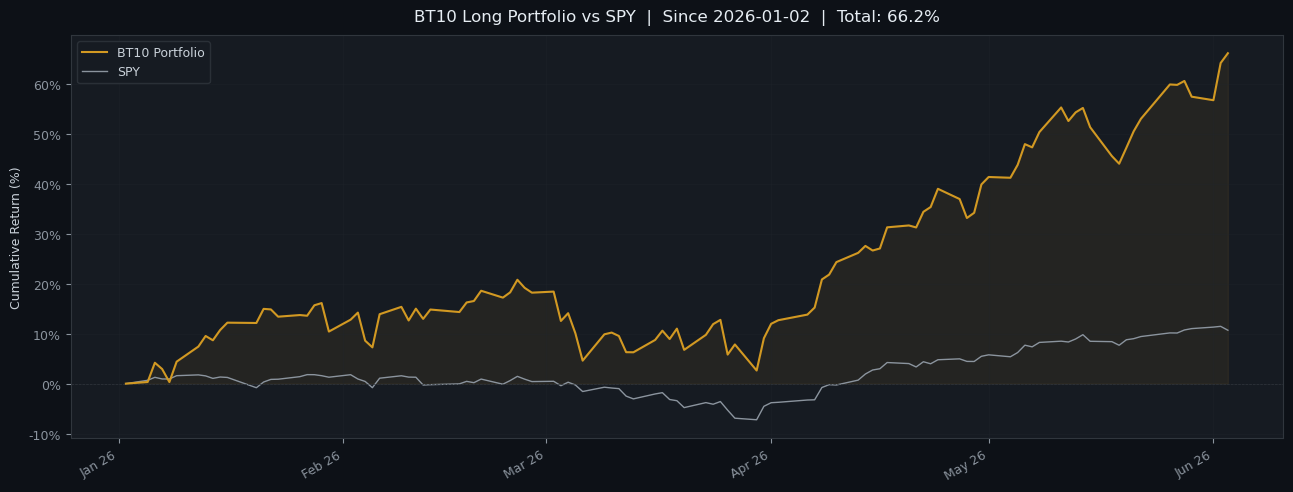

Chart saved.


In [14]:
# %% ── Equity curve chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')

cum_port = (1 + dl['ret_port']).cumprod() - 1
cum_spy  = (1 + dl['ret_spy']).cumprod()  - 1

ax.plot(dl['date'], cum_port * 100, color=C['gold'],
        linewidth=1.5, label='BT10 Portfolio', zorder=3)
ax.plot(dl['date'], cum_spy  * 100, color=C['grey'],
        linewidth=1.0, label='SPY', zorder=2)
ax.axhline(0, color='#30363d', linewidth=0.5, linestyle='--')

ax.fill_between(dl['date'], cum_port * 100, 0,
                where=cum_port >= 0,
                alpha=0.08, color=C['gold'])

ax.set_title(f"BT10 Long Portfolio vs SPY  |  Since {port['inception_date']}  "
             f"|  Total: {tot_ret:.1%}",
             color='#e6edf3', fontsize=12, pad=10)
ax.set_ylabel("Cumulative Return (%)", color='#c9d1d9')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG['base_dir'], 'equity_curve.png'),
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Chart saved.")


In [15]:
# %% ── Risk metrics ────────────────────────────────────────────────────────────
r_all = dl['ret_port'].values[1:]   # drop inception 0-row
s_all = dl['ret_spy'].values[1:]
n     = len(r_all)

if n >= 5:
    tot_r   = float(np.prod(1 + r_all) - 1)
    ann_r   = float((1 + tot_r) ** (252 / n) - 1)
    ann_v   = float(r_all.std() * np.sqrt(252))
    sharpe  = ann_r / ann_v if ann_v > 0 else None
    dn_r    = r_all[r_all < 0]
    sortino = ann_r / (dn_r.std() * np.sqrt(252)) if len(dn_r) > 1 else None
    cum     = np.cumprod(1 + r_all)
    mdd     = float(np.max(1 - cum / np.maximum.accumulate(cum)))
    beta    = float(np.cov(r_all, s_all)[0,1] / np.var(s_all)) \
              if np.var(s_all) > 0 else None

    # Exit breakdown from trade log
    if os.path.exists(CFG['f_trades']):
        tr = pd.read_csv(CFG['f_trades'])
        sells = tr[tr['action'] == 'SELL']
        n_trail = (sells['exit_type'] == 'TRAIL').sum()
        n_cusum = (sells['exit_type'] == 'CUSUM').sum()
    else:
        n_trail = n_cusum = 0

    print("\nRISK METRICS:")
    print(f"  Total Return:      {tot_r:.1%}")
    print(f"  Ann. Return (est): {ann_r:.1%}")
    print(f"  Ann. Volatility:   {ann_v:.1%}")
    print(f"  Sharpe (est):      {sharpe:.3f}" if sharpe else "  Sharpe: —")
    print(f"  Sortino (est):     {sortino:.3f}" if sortino else "  Sortino: —")
    print(f"  Max Drawdown:      {-mdd:.1%}")
    print(f"  Beta vs SPY:       {beta:.3f}" if beta else "  Beta: —")
    print(f"  Days in market:    {n}")
    print(f"  Exits — Trail:     {n_trail}")
    print(f"  Exits — CUSUM:     {n_cusum}")



RISK METRICS:
  Total Return:      66.2%
  Ann. Return (est): 242.7%
  Ann. Volatility:   38.9%
  Sharpe (est):      6.232
  Sortino (est):     8.920
  Max Drawdown:      -15.1%
  Beta vs SPY:       2.031
  Days in market:    104
  Exits — Trail:     0
  Exits — CUSUM:     0


Plotting RS charts for all holdings...


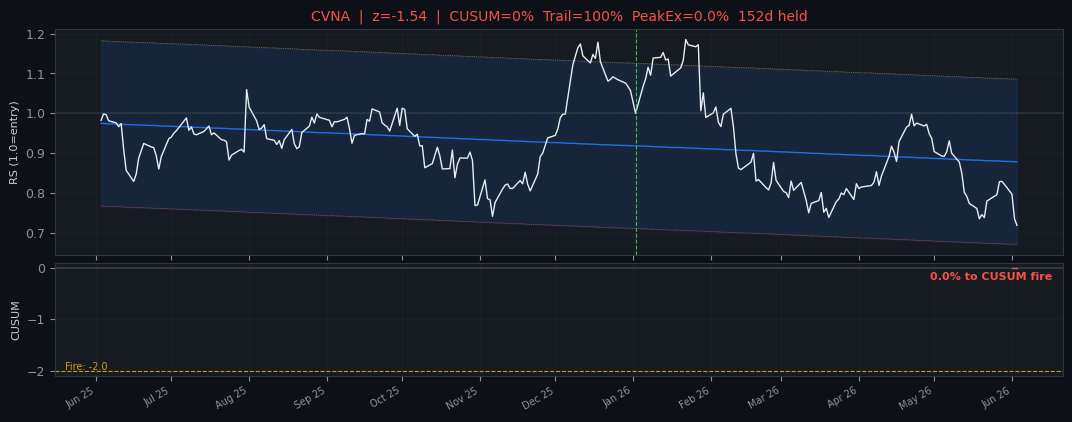

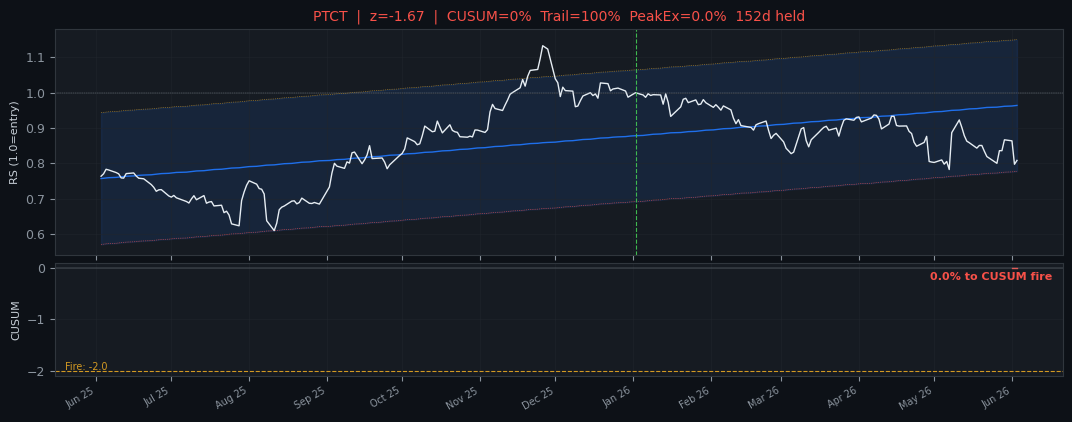

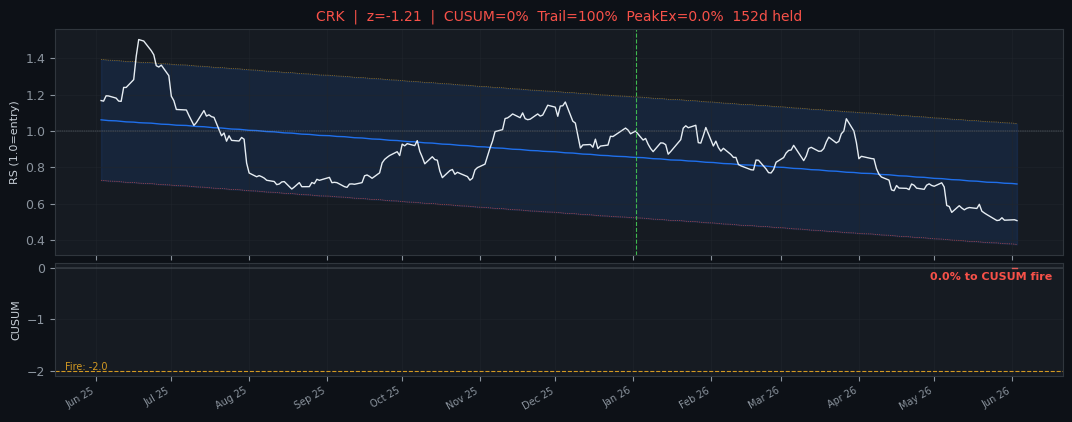

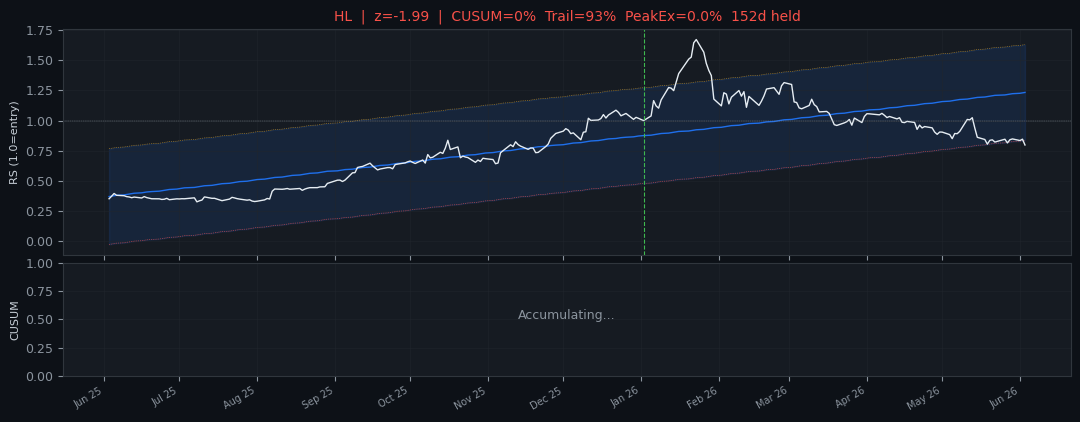

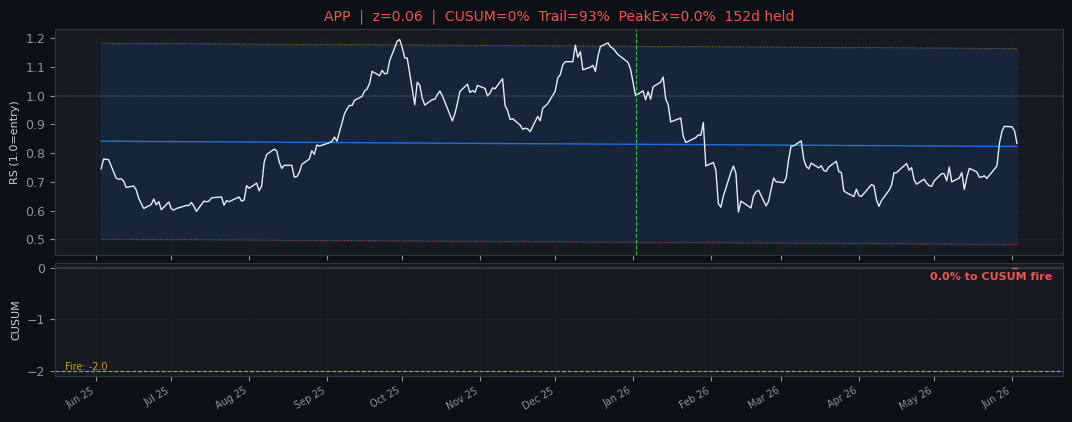

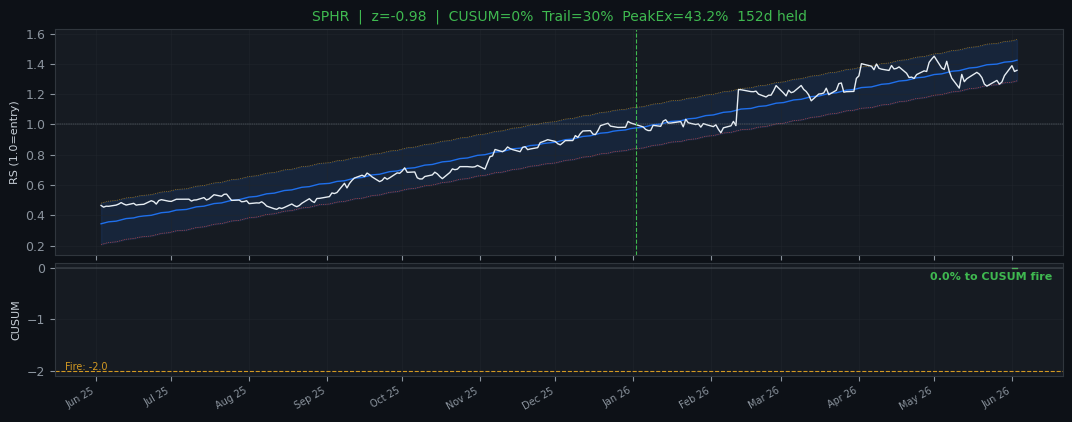

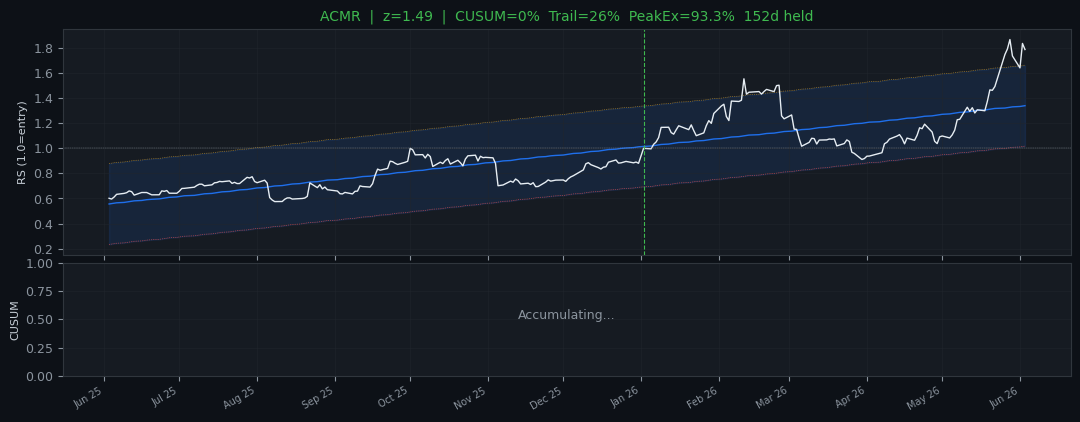

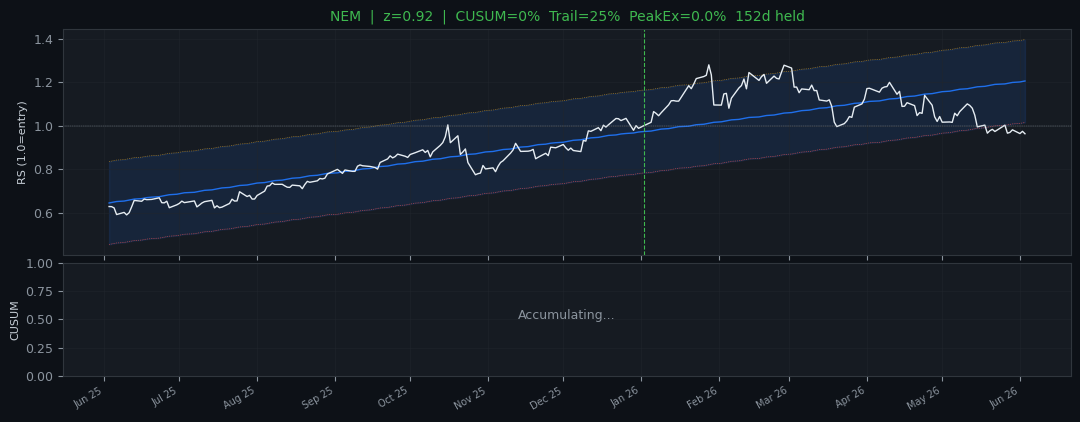

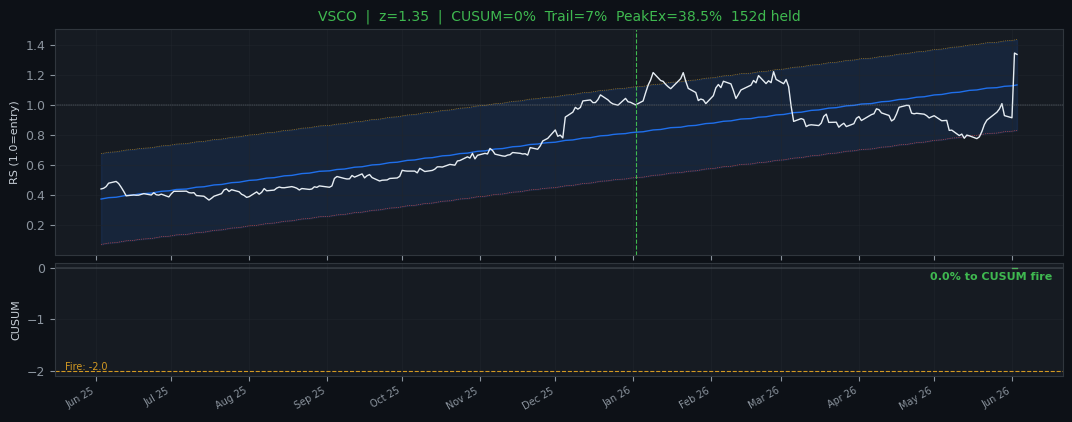

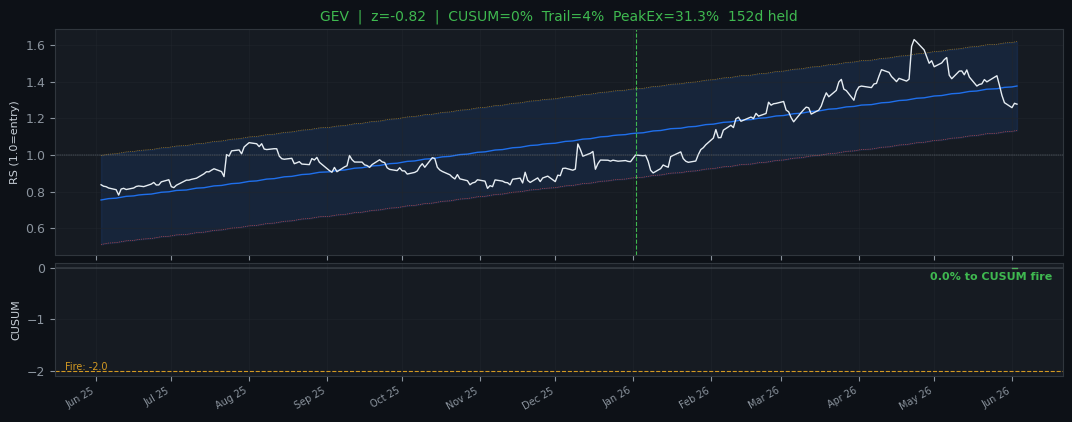

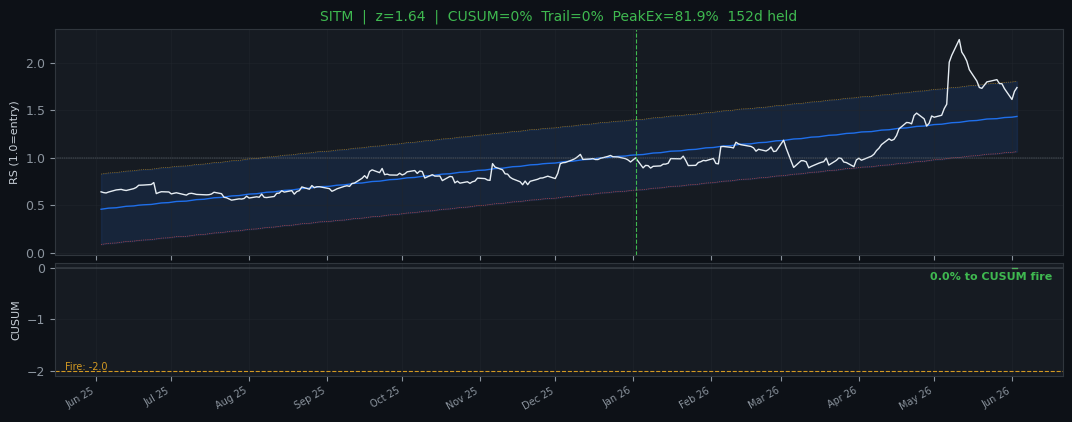

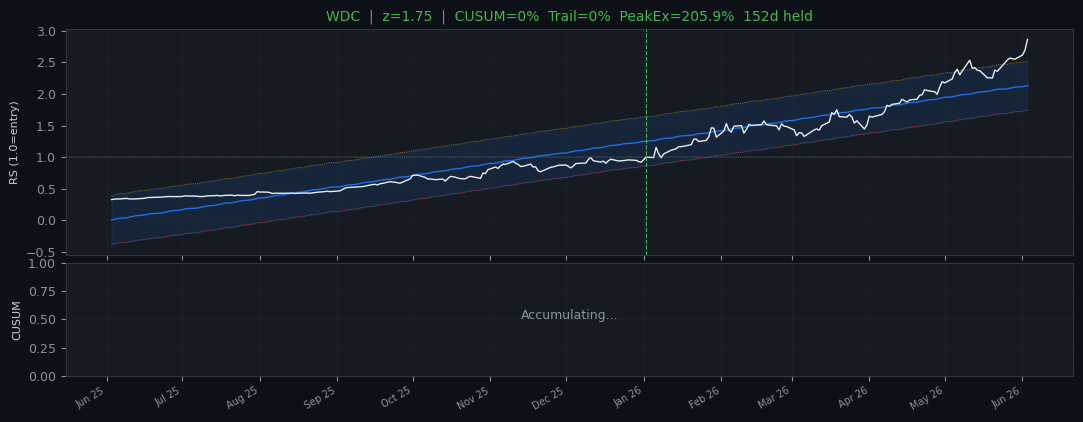

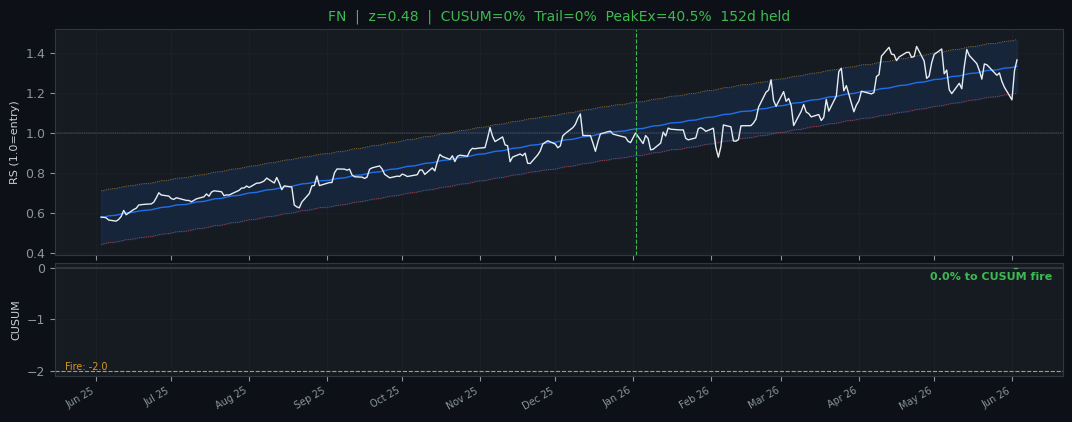

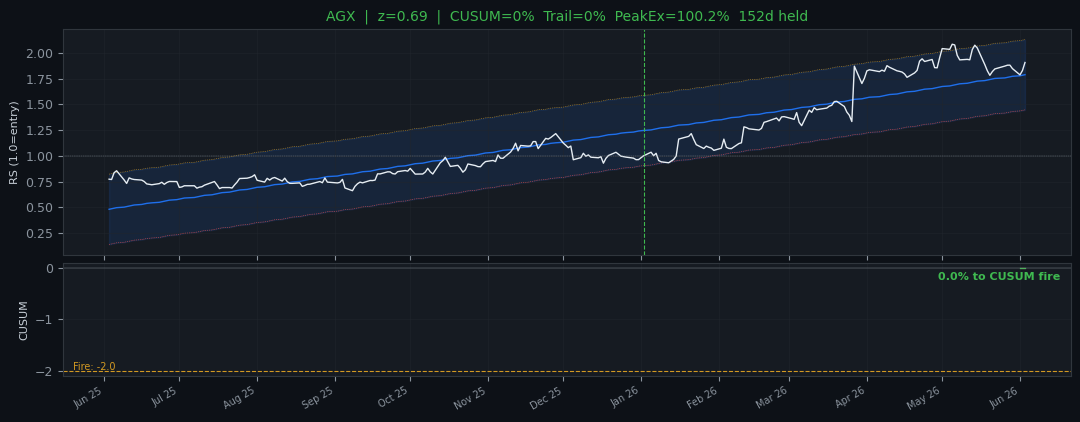

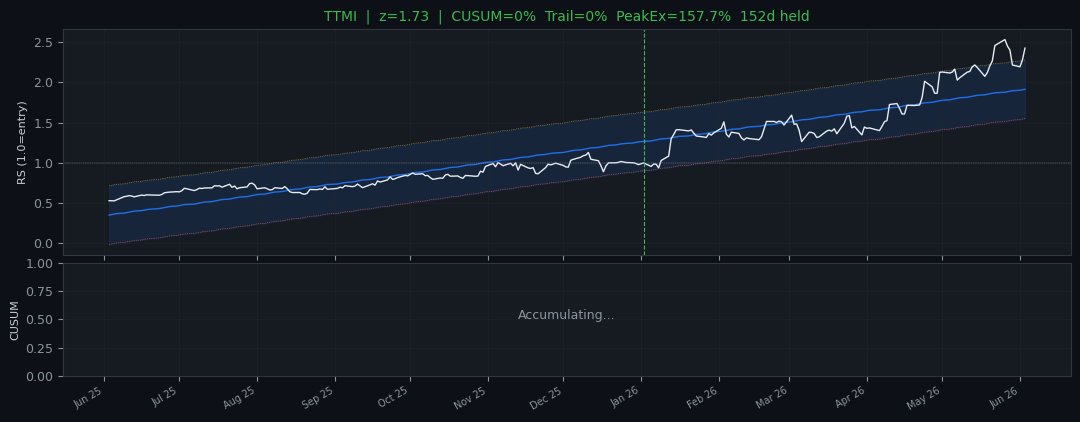

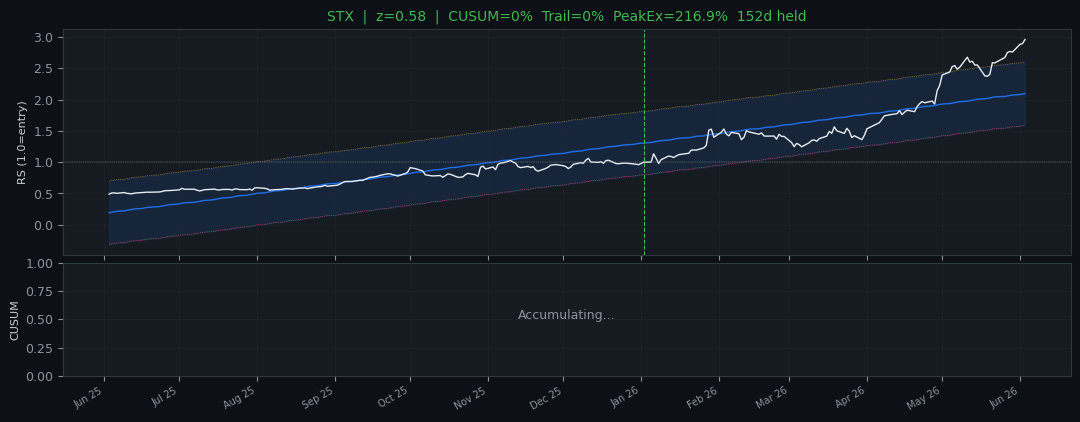

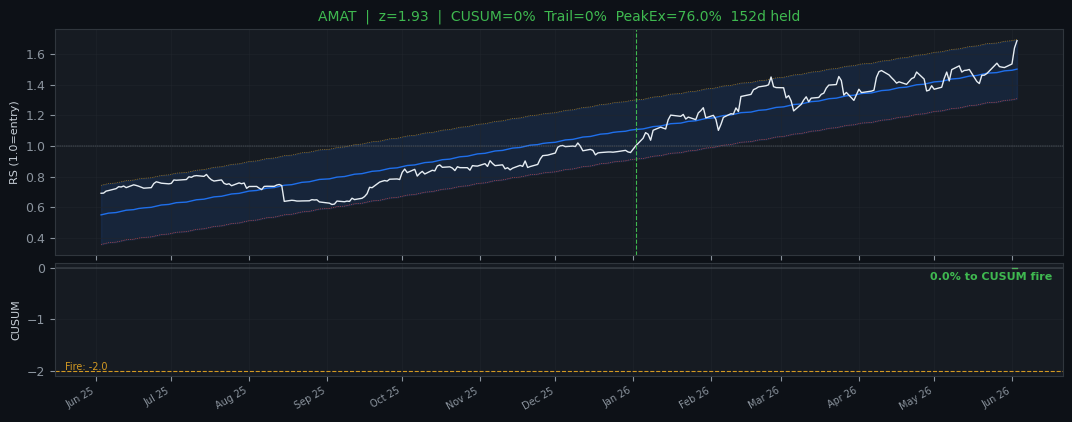

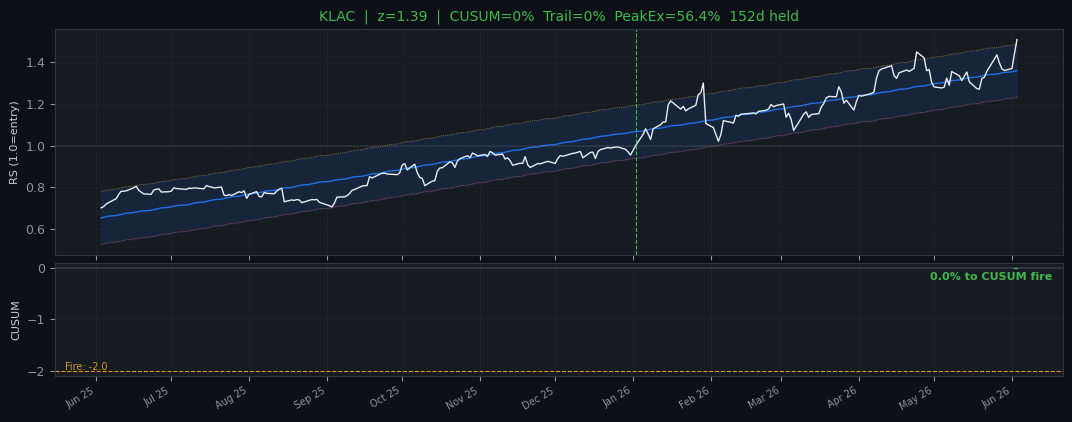

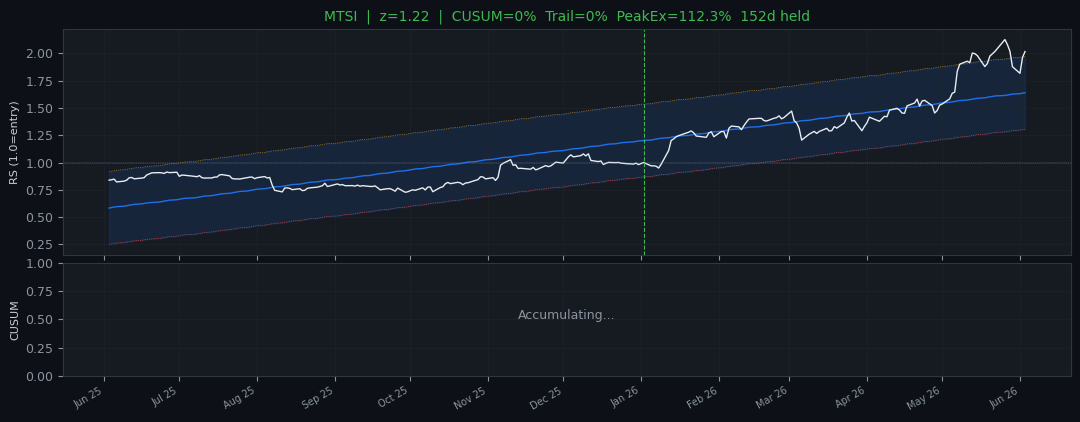

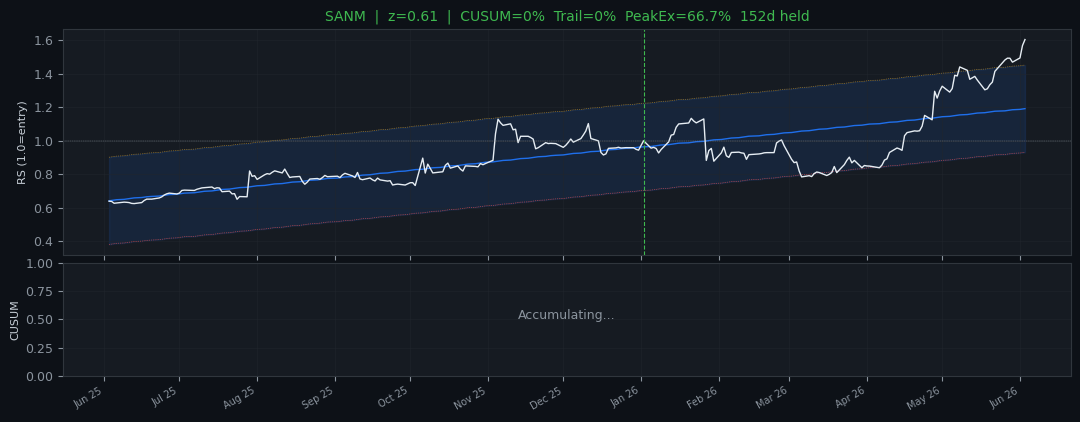

In [16]:
# %% ── RS charts for each holding ──────────────────────────────────────────────
def plot_rs_chart(sym, h, px_data=None):
    if px_data is None: px_data = px

    inc_ts   = pd.Timestamp(h['entry_date'])
    last_ts  = pd.Timestamp(LAST_DATE)
    lb_start = last_ts - pd.DateOffset(days=400)

    if sym not in px_data.columns: return
    sub = px_data.loc[lb_start:last_ts, [sym, CFG['benchmark']]].dropna()
    if len(sub) < 30: return

    rs    = (sub[sym] / sub[CFG['benchmark']]).values
    dates = sub.index
    n_use = min(CFG['lb_1y'], len(rs))
    rs_1y = rs[-n_use:]
    d_1y  = dates[-n_use:]

    t     = np.arange(len(rs_1y), dtype=float)
    b, a  = np.polyfit(t, rs_1y, 1)
    trend = a + b * t
    res   = rs_1y - trend
    se    = float(np.sqrt(np.sum(res**2) / max(len(rs_1y)-2, 1)))

    # Normalise to 1.0 at entry
    entry_idx = np.searchsorted(
        [d.date() for d in d_1y],
        date.fromisoformat(h['entry_date']))
    entry_idx = min(entry_idx, len(rs_1y)-1)
    ref = rs_1y[entry_idx] if rs_1y[entry_idx] != 0 else 1.0
    rs_n    = rs_1y / ref
    trend_n = trend / ref
    upper_n = (trend + CFG['sd_thresh'] * se) / ref
    lower_n = (trend - CFG['sd_thresh'] * se) / ref

    max_sig = max(h['cusum_pct'], h['trail_pct_to_fire'])
    col = (C['red']   if max_sig >= CFG['cusum_alert'] else
           C['gold']  if max_sig >= CFG['cusum_warn']  else C['green'])

    fig = plt.figure(figsize=(13, 4.5), facecolor='#0d1117')
    gs  = GridSpec(2, 1, height_ratios=[2,1], hspace=0.05)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    for ax in [ax1, ax2]:
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#8b949e')
        ax.spines[:].set_edgecolor('#30363d')
        ax.grid(True, color='#21262d', alpha=0.5)

    ax1.fill_between(d_1y, lower_n, upper_n,
                     color='#1f6feb', alpha=0.12)
    ax1.plot(d_1y, upper_n, color=C['gold'],
             linewidth=0.5, linestyle='dotted')
    ax1.plot(d_1y, lower_n, color=C['red'],
             linewidth=0.5, linestyle='dotted')
    ax1.plot(d_1y, trend_n, color='#1f6feb', linewidth=1.0)
    ax1.plot(d_1y, rs_n,    color='#e6edf3', linewidth=1.0)
    ax1.axhline(1.0, color='#8b949e', linewidth=0.3, linestyle='--')
    if entry_idx < len(d_1y):
        ax1.axvline(d_1y[entry_idx], color=C['green'],
                    linewidth=0.8, linestyle='--')

    ax1.set_title(
        f"{sym}  |  z={h['z_now']:.2f}  |  "
        f"CUSUM={h['cusum_pct']:.0f}%  Trail={h['trail_pct_to_fire']:.0f}%  "
        f"PeakEx={h['peak_excess']:.1%}  {h['days_held']}d held",
        color=col, fontsize=10, pad=6)
    ax1.set_ylabel("RS (1.0=entry)", color='#c9d1d9', fontsize=8)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # CUSUM panel
    zh   = h['cusum_z_hist']
    n_zh = len(zh)
    if n_zh >= 2:
        S = np.zeros(n_zh)
        for k, z in enumerate(zh):
            prev = S[k-1] if k > 0 else 0.0
            S[k] = min(0.0, prev + z + CFG['cusum_k']) \
                   if z < -CFG['cusum_gate'] else 0.0

        # Align to trading days from entry
        all_td = [d.date() for d in px_data.loc[
            pd.Timestamp(h['entry_date']):last_ts].index]
        cd = all_td[-n_zh:] if len(all_td) >= n_zh else all_td
        cd = [pd.Timestamp(d) for d in cd[:len(S)]]
        S  = S[:len(cd)]

        pct_f = round(abs(S[-1]) / CFG['cusum_h'] * 100, 1)
        ax2.fill_between(cd, S, 0, alpha=0.18, color=C['red'])
        ax2.plot(cd, S, color=col, linewidth=0.9)
        ax2.axhline(-CFG['cusum_h'], color=C['gold'],
                    linewidth=0.8, linestyle='--')
        ax2.axhline(0, color='#8b949e', linewidth=0.3)
        ax2.text(0.01, 0.05, f"Fire: -{CFG['cusum_h']}",
                 transform=ax2.transAxes,
                 color=C['gold'], fontsize=7)
        ax2.text(0.99, 0.85, f"{pct_f}% to CUSUM fire",
                 transform=ax2.transAxes, ha='right',
                 color=col, fontsize=8, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'Accumulating...', ha='center',
                 transform=ax2.transAxes, color='#8b949e')

    ax2.set_ylabel("CUSUM", color='#c9d1d9', fontsize=8)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    plt.tight_layout()
    plt.savefig(
        os.path.join(CFG['base_dir'], f"rs_{sym}.png"),
        dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    plt.close()

print("Plotting RS charts for all holdings...")
for sym, h in sorted(port['holdings'].items(),
    key=lambda x: max(x[1]['cusum_pct'],
                      x[1]['trail_pct_to_fire']), reverse=True):
    plot_rs_chart(sym, h)


In [17]:
# %% ── Top 100 long rankings ───────────────────────────────────────────────────
print("\nTOP 100 LONG CANDIDATES:")
print(f"{'Rank':>4} {'Ticker':<7} {'Sector':<25} "
      f"{'Score':>6} {'Z':>6} {'Slp1Y':>8} "
      f"{'PnF':>6} {'ExVol':>7} {'Thresh':>7} {'Price':>8}")
print("-" * 90)
held = set(port['holdings'].keys())
for i, row in cand_sc.head(100).iterrows():
    rank  = i + 1
    sym   = row['ticker']
    held_marker = '*' if sym in held else ' '
    thresh = CFG['trail_n'] * row['ann_ex_vol']
    print(
        f"{rank:>4}{held_marker} {sym:<7} {row['sector']:<25} "
        f"{row['composite']:>6.4f} {row['z_now']:>6.2f} "
        f"{row['slope_1y']:>8.5f} {row['pnf']:>6.1%} "
        f"{row['ann_ex_vol']:>7.1%} {thresh:>7.1%} "
        f"{row['last_px']:>8.2f}"
    )


TOP 100 LONG CANDIDATES:
Rank Ticker  Sector                     Score      Z    Slp1Y    PnF   ExVol  Thresh    Price
------------------------------------------------------------------------------------------
   1  LITE    Communication Services    0.8654  -0.03  0.00537  75.0%  100.0%   33.0%   938.00
   2  ICHR    Technology                0.8582   0.93  0.00028  69.0%   70.6%   23.3%    72.45
   3  UCTT    Technology                0.8561   1.35  0.00035  60.0%   69.5%   22.9%    92.55
   4  CIEN    Communication Services    0.8552   1.72  0.00279  51.0%   69.1%   22.8%   620.37
   5  MP      Materials                 0.8530   0.02  0.00001 147.0%   67.5%   22.3%    68.55
   6  GLW     Technology                0.8511   1.32  0.00072  54.0%   69.7%   23.0%   200.76
   7  CLSK    Financials                0.8464   1.41 -0.00001 114.0%   60.6%   20.0%    17.61
   8  NXT     Energy                    0.8418   0.63  0.00039  87.0%   69.4%   22.9%   146.47
   9  TER     Technology     

In [18]:
# %% ── Trade log ───────────────────────────────────────────────────────────────
if os.path.exists(CFG['f_trades']):
    tr = pd.read_csv(CFG['f_trades'])
    print(f"\nTRADE LOG (last 30 of {len(tr)} trades):")
    print(tr.tail(30).to_string(index=False))
else:
    print("No trades yet.")


TRADE LOG (last 30 of 20 trades):
      date action ticker                 sector  shares     price   value  exit_type                 reason  portfolio_value
2026-01-02    BUY   SITM             Technology      20  370.0525 7401.05        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY    WDC             Technology      39  187.6571 7318.63        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY     FN             Technology      15  479.5399 7193.10        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY     HL              Materials     395   18.8714 7454.20        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY    AGX              Materials      22  325.4480 7159.86        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY   TTMI             Technology     105   70.6277 7415.91        NaN Initial BT10 portfolio        150000.01
2026-01-02    BUY    APP             Technology      12  618.4746 7421.70        NaN Initi

In [ ]:
# %% ── Email alert ─────────────────────────────────────────────────────────────
def send_email_alert(port, cand_sc):
    """Send daily email with portfolio summary and trade signals."""
    if not CFG['send_email']:
        print("[EMAIL SUPPRESSED]")
        return

    n_sell = len(port['pending_sells'])
    n_buy  = len(port['pending_buys'])
    tot_r  = (port['total_value'] - port['inception_value']) / \
              port['inception_value']

    # Positions nearest to exit
    near_exit = sorted(
        port['holdings'].items(),
        key=lambda x: max(x[1]['cusum_pct'], x[1]['trail_pct_to_fire']),
        reverse=True)[:5]

    lines = [
        f"BT10 Daily Update — {LAST_DATE}",
        f"Portfolio: ${port['total_value']:,.0f}  "
        f"Return: {tot_r:.1%}",
        "",
    ]
    if n_sell:
        lines.append(f"SELL TODAY: {', '.join(port['pending_sells'])}")
    if n_buy:
        lines.append(f"BUY TODAY:  {', '.join(port['pending_buys'])}")
    lines += ["", "NEAREST TO EXIT:"]
    for sym, h in near_exit:
        lines.append(
            f"  {sym}: CUSUM={h['cusum_pct']:.0f}%  "
            f"Trail={h['trail_pct_to_fire']:.0f}%")

    body    = "\n".join(lines)
    subject = (f"BT10 | {LAST_DATE} | {tot_r:.1%}" +
               (f" | SELL: {','.join(port['pending_sells'])}"
                if n_sell else "") +
               (f" | BUY: {','.join(port['pending_buys'])}"
                if n_buy else ""))

    try:
        msg = MIMEMultipart()
        msg['From']    = CFG['email_from']
        msg['To']      = CFG['email_to']
        msg['Subject'] = subject
        msg.attach(MIMEText(body, 'plain'))
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as s:
            s.login(CFG['email_from'], CFG['email_password'])
            s.send_message(msg)
        print(f"Email sent: {subject}")
    except Exception as e:
        print(f"Email failed: {e}")

send_email_alert(port, cand_sc)

print("\n" + "=" * 60)
print(f"  BT10 run complete — {LAST_DATE}")
print("=" * 60)

In [ ]:
# ── REPAIR: Backfill daily log for existing portfolio ─────────────────────────
import pandas as pd, numpy as np, json
from datetime import date

# Load current state
with open(CFG['f_portfolio']) as f:
    port = json.load(f)

port['inception_date'] = date.fromisoformat(port['inception_date'])
inc_date = port['inception_date']

# Get initial holdings from trade log
trades     = pd.read_csv(CFG['f_trades'])
init_buys  = trades[trades['action']=='BUY']
init_shares= dict(zip(init_buys['ticker'], init_buys['shares'].astype(int)))
init_costs = dict(zip(init_buys['ticker'], init_buys['price'].astype(float)))
init_cash  = CFG['initial_capital'] - sum(
    init_shares[s]*init_costs[s] for s in init_shares)

# All trading days since inception in px
all_dates = [d.date() for d in px.index if d.date() >= inc_date]
print(f"Backfilling {len(all_dates)} days from {min(all_dates)} to {max(all_dates)}")

log_rows = []
for dt in all_dates:
    dt_ts = pd.Timestamp(dt)
    mv = sum(
        init_shares[sym] * float(px.loc[dt_ts, sym])
        for sym in init_shares
        if sym in px.columns
        and not np.isnan(float(px.loc[dt_ts, sym]))
        and float(px.loc[dt_ts, sym]) > 0
    )
    spy = None
    if CFG['benchmark'] in px.columns:
        v = float(px.loc[dt_ts, CFG['benchmark']])
        if not np.isnan(v): spy = round(v, 4)

    log_rows.append(dict(
        date=str(dt), tot_value=round(mv+init_cash,2),
        cash=round(init_cash,2), spy_px=spy, n_holdings=len(init_shares)))

# Verify
spy_v = [r['spy_px'] for r in log_rows if r['spy_px']]
print(f"SPY:  {spy_v[0]:.2f} → {spy_v[-1]:.2f} = {spy_v[-1]/spy_v[0]-1:.1%}")
print(f"Port: {log_rows[0]['tot_value']:,.0f} → "
      f"{log_rows[-1]['tot_value']:,.0f} = "
      f"{log_rows[-1]['tot_value']/log_rows[0]['tot_value']-1:.1%}")

# Save
port['daily_log'] = log_rows
p = port.copy()
p['inception_date']   = str(p['inception_date'])
p['last_signal_date'] = str(p['last_signal_date']) \
    if p.get('last_signal_date') else None
with open(CFG['f_portfolio'], 'w') as f:
    json.dump(p, f, indent=2, default=str)

print(f"Saved. Re-run all cells from 'Performance series' downward.")